# Blackjack mit Q-Learning

Dieses Notebook trainiert und evaluiert einen **Baseline-Agenten** und einen Agenten mit **Kartenzählung**. Alle Grafiken werden zentral in `utils.visualization` erzeugt, als einzelne PNG-Dateien gespeichert und anschließend gezielt angezeigt.


## Ablauf

1. Setup und Experimentkonfiguration
2. Umgebung und Agenten
3. Training und Trainingsdiagnostik
4. Greedy-Evaluation mit Konfidenzintervallen
5. True-Count-Bucket-Auswertung
6. Repräsentative Policy- und Q-Value-Analyse


# 1. Setup

## 1.1 Imports und Projektpfade


In [1]:
from collections import defaultdict
from datetime import datetime
from pathlib import Path
from typing import cast
import sys

import gymnasium as gym
import ipywidgets as widgets
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "env" / "blackjack_env.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from agents.q_learning_agent import QLearningBlackjackAgent
from env.blackjack_env import BlackjackEnv
from utils.env_utils import make_blackjack_env
from utils.evaluation import (
    TRUE_COUNT_BUCKET_SUMMARY_COLUMNS,
    build_true_count_bucket_tasks,
    calculate_evaluation_cis,
    evaluate_single_agent_parallel,
    evaluate_true_count_buckets_parallel,
    prepare_true_count_bucket_reports,
)
from utils.training import run_parallel_with_dashboard, train_single_agent
from utils.visualization import (
    AGENT_STYLES,
    display_saved_images,
    make_figure_saver,
    plot_all_agent_policy_and_q_values,
    plot_all_true_count_bucket_metrics,
    plot_evaluation_metrics_with_cis,
    plot_training_rewards,
    plot_training_td_error,
    select_policy_preview_paths,
    setup_plot_style,
)


## 1.2 Bildausgabe und Plotstil

Die Ausgabe wird automatisch in thematische Unterordner von `images/` sortiert. Alle Plotfunktionen verwenden dieselbe Grundkonfiguration.


In [2]:
IMAGES_PATH = PROJECT_ROOT / "images"
save_fig = make_figure_saver(IMAGES_PATH)
setup_plot_style()


# 2. Umgebung und Agenten

## 2.1 Zustandskodierung und Agentenklassen


In [3]:
def baseline_state_key(obs) -> tuple[int, int, int]:
    player_total, dealer_upcard, usable_ace = obs[:3]

    return (
        int(player_total),
        int(dealer_upcard),
        int(usable_ace)
    )

def counting_state_key(obs: np.ndarray):
    # Lokaler Import: Die Funktion wird unter Windows in Worker-Prozesse serialisiert.
    import numpy as np

    player_total, dealer_upcard, usable_ace, running_count, true_count, cards_remaining = obs

    return (
        int(player_total),
        int(dealer_upcard),
        int(usable_ace),

        int(np.clip(running_count, -20, 20)),
        int(np.clip(true_count, -10, 10)),
        int(np.clip(cards_remaining // 52, 0, 6)),
    )


class BaselineBlackjackAgent(QLearningBlackjackAgent):
    def __init__(
            self, 
            env: gym.Env,
            **kwargs):
        
        super().__init__(
            env=env,
            state_encoder=baseline_state_key,
            **kwargs,
        )
        
class CountingBlackjackAgent(QLearningBlackjackAgent):
    def __init__(
            self, 
            env: gym.Env,
            **kwargs):
        
        super().__init__(
            env=env,
            state_encoder=counting_state_key,
            **kwargs,
        )


## 2.2 Experimentkonfiguration und Agenteninstanzen

Training und Evaluation verwenden getrennte Seeds. Anschließend werden je Seed ein Baseline- und ein Counting-Agent erzeugt.


In [4]:
SEEDS = [1, 42, 123]
EPISODES_PER_SEED = 100_000_000
EVAL_SEEDS = [1234, 4321, 9876]
EVAL_EPISODES = 1_000_000
CHECKPOINT_INTERVAL = 10_000_000
TRAINING_HISTORY_LIMIT = 100_000
SAVE_FINAL_MODELS = True
MODEL_DIR = PROJECT_ROOT / "models"
CHECKPOINT_DIR = MODEL_DIR / "checkpoints"
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

agent_config = {
    "learning_rate": 0.01,
    "initial_epsilon": 1.0,
    "final_epsilon": 0.10,
    "epsilon_decay": (1.0 - 0.10) / (EPISODES_PER_SEED * 0.90),
    "discount_factor": 0.99,
}

def make_env(seed: int, n_episodes: int):
    env = BlackjackEnv(
        num_decks=6,
        penetration=0.75,
        stand_on_soft_17=True,
    )

    env = gym.wrappers.RecordEpisodeStatistics(
        env,
        buffer_length=min(n_episodes, TRAINING_HISTORY_LIMIT),
    )

    env.reset(seed=seed)
    env.action_space.seed(seed)

    return env

agents = {}

for seed in SEEDS:
    agents[f"baseline-{seed}"] = BaselineBlackjackAgent(
        env=make_env(seed, EPISODES_PER_SEED),
        **agent_config,
    )
    agents[f"counting-{seed}"] = CountingBlackjackAgent(
        env=make_env(seed, EPISODES_PER_SEED),
        **agent_config,
    )

def split_agent_name(name: str) -> tuple[str, int]:
    agent_type, seed = name.rsplit("-", 1)
    return agent_type, int(seed)

def group_agents_by_type(agents):
    grouped = defaultdict(list)

    for name, agent in agents.items():
        agent_type, seed = split_agent_name(name)
        grouped[agent_type].append((seed, agent))

    return grouped


## 2.3 Modell- und Checkpoint-Auswahl

Für jeden Agenten kann ein bestehendes Artefakt ausgewählt werden. `Neu trainieren` startet ohne gespeichertes Modell.


In [5]:
# Checkpoint-Auswahl fuer Training und Evaluation
NO_ARTIFACT = None
IN_MEMORY_ARTIFACT = "__in_memory__"

def artifact_label(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)

def artifact_options(agent_name: str, include_fresh: bool = False, include_memory: bool = False):
    options = []
    if include_fresh:
        options.append(("Neu trainieren (kein gespeichertes Modell laden)", NO_ARTIFACT))
    if include_memory:
        options.append(("Aktueller Agent im Speicher", IN_MEMORY_ARTIFACT))

    candidates = []
    final_model_suffix = f"_{agent_name}_agent.pkl"
    candidates.extend(
        path for path in MODEL_DIR.glob("*.pkl")
        if path.name.endswith(final_model_suffix)
    )
    candidates.extend((CHECKPOINT_DIR / agent_name).glob("*.pkl"))
    candidates = sorted(
        {path.resolve(): path for path in candidates}.values(),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )

    options.extend((artifact_label(path), str(path)) for path in candidates)
    return options

TRAIN_ARTIFACT_SELECTORS = {
    name: widgets.Dropdown(
        options=artifact_options(name, include_fresh=True),
        value=NO_ARTIFACT,
        description=f"{name}:",
        layout=widgets.Layout(width="760px"),
    )
    for name in agents
}

display(widgets.VBox([widgets.HTML("<b>Training fortsetzen ab:</b>"), *TRAIN_ARTIFACT_SELECTORS.values()]))


# 3. Training

## 3.1 Paralleles Training

Die Fortschrittsanzeige fasst alle Agenten zusammen. Checkpoints werden entsprechend der Experimentkonfiguration geschrieben.


In [ ]:
if __name__ == "__main__":
    tasks = []
    for name, agent in agents.items():
        agent_type, seed = split_agent_name(name)
        selected_artifact = TRAIN_ARTIFACT_SELECTORS[name].value

        tasks.append((
            name, agent, agent_type, seed, selected_artifact,
            EPISODES_PER_SEED, CHECKPOINT_INTERVAL, CHECKPOINT_DIR / name, RUN_ID, TRAINING_HISTORY_LIMIT
        ))

    results = run_parallel_with_dashboard(
        worker_func=train_single_agent,
        base_tasks=tasks,
        agent_names=list(agents.keys()),
        max_value_per_agent=EPISODES_PER_SEED,
        title="Training"
    )

    for name, trained_agent in results:
        agents[name] = trained_agent


## 3.2 Finale Modelle speichern


In [ ]:
timestamp = RUN_ID

MODEL_DIR.mkdir(parents=True, exist_ok=True)

if SAVE_FINAL_MODELS:
    for name, agent in agents.items():
        agent_type, seed = split_agent_name(name)
        print(f"Saving {name} agent...")
        
        filename = f"{timestamp}_{name}_agent.pkl"
        path = MODEL_DIR / filename
        
        agent.save(
            path,
            label=f"{name}_{timestamp}",
            artifact_type="final",
            episode=EPISODES_PER_SEED,
            n_episodes=EPISODES_PER_SEED,
            base_seed=seed,
            metadata={
                "agent_name": name,
                "agent_type": agent_type,
                "run_id": RUN_ID,
                "seed": seed,
                "target_episode": EPISODES_PER_SEED,
            },
            include_history=False,
        )
        print(f"-> Erfolgreich gespeichert unter: {path}")
else:
    print("Finales Speichern ist deaktiviert (SAVE_FINAL_MODELS=False).")


## 3.3 Trainingsverlauf

Reward und TD Error werden jeweils als eigene Grafik gespeichert und hier direkt aus den PNG-Dateien angezeigt.


In [ ]:
training_plot_paths = [
    plot_training_rewards(
        agents,
        split_agent_name_func=split_agent_name,
        agent_styles=AGENT_STYLES,
        save_fig_func=save_fig,
        window=1000,
    ),
    plot_training_td_error(
        agents,
        split_agent_name_func=split_agent_name,
        agent_styles=AGENT_STYLES,
        save_fig_func=save_fig,
        window=5000,
    ),
]

display_saved_images(training_plot_paths, title="Training")


## 3.4 Trainingsmetriken

Die erste Tabelle zeigt die Ergebnisse pro Seed, die zweite aggregiert alle Trainingsläufe je Agententyp.


In [ ]:
def get_reward_matrix(agent_list):
    return np.vstack([
        np.asarray(agent.episode_rewards)
        for seed, agent in agent_list
    ])


def flatten_rewards(agent_list):
    return get_reward_matrix(agent_list).ravel()


def calculate_metrics(rewards: np.ndarray) -> dict:
    rewards = np.asarray(rewards)

    wins = np.sum(rewards == 1)
    losses = np.sum(rewards == -1)
    pushes = np.sum(rewards == 0)
    total = len(rewards)

    return {
        "win_rate": wins / total if total > 0 else 0.0,
        "loss_rate": losses / total if total > 0 else 0.0,
        "push_rate": pushes / total if total > 0 else 0.0,
        "average_reward": np.mean(rewards) if total > 0 else 0.0,
        "std_reward": np.std(rewards) if total > 0 else 0.0,
    }


grouped = group_agents_by_type(agents)

per_seed_rows = []
for agent_type, agent_list in grouped.items():
    for seed, agent in agent_list:
        row = calculate_metrics(np.asarray(agent.episode_rewards))
        row.update({"agent_type": agent_type, "seed": seed})
        per_seed_rows.append(row)

per_seed_metrics_df = pd.DataFrame(per_seed_rows).sort_values(["agent_type", "seed"])
display(per_seed_metrics_df)

baseline_rewards = flatten_rewards(grouped["baseline"])
counting_rewards = flatten_rewards(grouped["counting"])

baseline_metrics = calculate_metrics(baseline_rewards)
counting_metrics = calculate_metrics(counting_rewards)

summary_metrics_df = pd.DataFrame({
    "baseline": baseline_metrics,
    "counting": counting_metrics,
}).T
display(summary_metrics_df)

for name, metrics in [("Baseline", baseline_metrics), ("Counting", counting_metrics)]:
    print(f"{name} metrics:")
    print(f"  Win Rate:       {metrics['win_rate']:.1%}")
    print(f"  Loss Rate:      {metrics['loss_rate']:.1%}")
    print(f"  Push Rate:      {metrics['push_rate']:.1%}")
    print(f"  Avg Reward:     {metrics['average_reward']:.3f}")
    print(f"  Std Reward:     {metrics['std_reward']:.3f}")
    print()


# 4. Greedy-Evaluation

## 4.1 Evaluationsmodelle auswählen

Standardmäßig wird der aktuelle Agent im Speicher verwendet. Alternativ kann pro Agent ein gespeichertes Modell ausgewählt werden.


In [6]:
# Auswahl, welches Modell/Checkpoint evaluiert werden soll
def default_eval_artifact(agent_name: str):
    in_memory_q_values = getattr(agents[agent_name], "q_values", {})
    if in_memory_q_values:
        return IN_MEMORY_ARTIFACT

    selected_training_artifact = TRAIN_ARTIFACT_SELECTORS[agent_name].value
    if selected_training_artifact is not None:
        return selected_training_artifact

    stored_artifacts = artifact_options(agent_name)
    return stored_artifacts[0][1] if stored_artifacts else IN_MEMORY_ARTIFACT


EVAL_ARTIFACT_SELECTORS = {
    name: widgets.Dropdown(
        options=artifact_options(name, include_memory=True),
        value=default_eval_artifact(name),
        description=f"{name}:",
        layout=widgets.Layout(width="760px"),
    )
    for name in agents
}

display(widgets.VBox([
    widgets.HTML("<b>Evaluationsmodell auswählen:</b>"),
    *EVAL_ARTIFACT_SELECTORS.values(),
]))


## 4.2 Hilfsfunktionen und Ausgabepfad


In [7]:
def require_eval_artifacts():
    if "EVAL_ARTIFACT_SELECTORS" not in globals():
        raise RuntimeError(
            "Bitte zuerst die Evaluation-Artefakte auswählen."
        )


def get_evaluation_dir() -> Path:
    evaluation_dir = Path(MODEL_DIR) / "evaluations" / RUN_ID
    evaluation_dir.mkdir(parents=True, exist_ok=True)
    globals()["EVALUATION_DIR"] = evaluation_dir
    return evaluation_dir


## 4.3 Evaluation ausführen

Jeder Agent wird mit mehreren unabhängigen Evaluations-Seeds getestet.


In [8]:
AGENT_CLASSES = {
    "baseline": BaselineBlackjackAgent,
    "counting": CountingBlackjackAgent,
}

def make_agent(agent_name: str, seed: int):
    agent_type, _ = split_agent_name(agent_name)
    return AGENT_CLASSES[agent_type](
        env=make_blackjack_env(seed=seed, n_episodes=EVAL_EPISODES), # <- Korrigiert
        **agent_config,
    )

def selected_eval_agent(agent_name: str):
    selected_artifact = EVAL_ARTIFACT_SELECTORS[agent_name].value
    in_memory_agent = agents[agent_name]

    if selected_artifact == IN_MEMORY_ARTIFACT and getattr(in_memory_agent, "q_values", {}):
        return in_memory_agent, "in_memory"

    if selected_artifact == IN_MEMORY_ARTIFACT:
        selected_artifact = TRAIN_ARTIFACT_SELECTORS[agent_name].value

    if selected_artifact is None:
        stored_artifacts = artifact_options(agent_name)
        selected_artifact = stored_artifacts[0][1] if stored_artifacts else None

    if selected_artifact is None:
        raise RuntimeError(
            f"Für {agent_name} ist weder ein trainierter Agent im Speicher noch ein gespeichertes Modell verfügbar."
        )

    _, seed = split_agent_name(agent_name)
    eval_agent = make_agent(agent_name, seed=seed)
    artifact = eval_agent.load(selected_artifact)
    label = artifact.get("label") or artifact_label(Path(selected_artifact))
    return eval_agent, label


def eval_task_name(agent_name: str, eval_seed: int) -> str:
    return f"{agent_name}__eval_seed_{eval_seed}"


def split_eval_task_name(task_name: str) -> tuple[str, int]:
    agent_name, eval_seed = task_name.rsplit("__eval_seed_", 1)
    return agent_name, int(eval_seed)


if __name__ == "__main__":
    tasks = []
    agent_names = []
    
    for name in agents:
        eval_agent, source_label = selected_eval_agent(name)
        agent_type, _ = split_agent_name(name)
        
        encoder_func = baseline_state_key if agent_type == "baseline" else counting_state_key
        
        for eval_seed in EVAL_SEEDS:
            task_name = eval_task_name(name, eval_seed)
            agent_names.append(task_name)
            tasks.append((
                task_name,
                eval_agent.q_values,
                encoder_func,
                source_label,
                EVAL_EPISODES,
                eval_seed,
            ))
        
    results = run_parallel_with_dashboard(
        worker_func=evaluate_single_agent_parallel,
        base_tasks=tasks,
        agent_names=agent_names,
        max_value_per_agent=EVAL_EPISODES,
        title="Evaluation"
    )
    
    greedy_eval_results = {}
    for task_name, metrics in results:
        agent_name, eval_seed = split_eval_task_name(task_name)
        agent_type, train_seed = split_agent_name(agent_name)
        metrics.update({
            "agent_name": agent_name,
            "agent_type": agent_type,
            "train_seed": train_seed,
            "eval_seed": eval_seed,
        })
        greedy_eval_results[task_name] = metrics

    greedy_eval_df = pd.DataFrame(greedy_eval_results).T
    EVALUATION_DIR = get_evaluation_dir()
    greedy_eval_df.to_csv(EVALUATION_DIR / "greedy_metrics.csv", index_label="eval_run")
    greedy_eval_df.to_json(EVALUATION_DIR / "greedy_metrics.json", orient="index", indent=2)
    print(f"Evaluation gespeichert unter: {EVALUATION_DIR}")
    display(greedy_eval_df)


Initialisiere paralleles Evaluation-Dashboard...



Prozess erfolgreich beendet! Gesamtdauer: 0:05:41
Evaluation gespeichert unter: E:\tomni\Documents\01_Code\ml-blackjack\models\evaluations\20260610_164317


,source,episodes,win_rate,loss_rate,push_rate,average_reward,std_reward,action_distribution,agent_name,agent_type,train_seed,eval_seed
baseline-1__eval_seed_1234,20260608_170145_baseline-1_agent,1000000,0.426643,0.47856,0.094797,-0.051917,0.950004,"{'stand': 811303, 'hit': 759116}",baseline-1,baseline,1,1234
baseline-1__eval_seed_4321,20260608_170145_baseline-1_agent,1000000,0.426657,0.478505,0.094838,-0.051848,0.949986,"{'stand': 811254, 'hit': 759123}",baseline-1,baseline,1,4321
baseline-1__eval_seed_9876,20260608_170145_baseline-1_agent,1000000,0.426678,0.478546,0.094776,-0.051868,0.950018,"{'stand': 811237, 'hit': 759343}",baseline-1,baseline,1,9876
counting-1__eval_seed_1234,20260608_170145_counting-1_agent,1000000,0.428452,0.477823,0.093725,-0.049371,0.950704,"{'stand': 816223, 'hit': 745544}",counting-1,counting,1,1234
counting-1__eval_seed_4321,20260608_170145_counting-1_agent,1000000,0.428506,0.477801,0.093693,-0.049295,0.950724,"{'stand': 816239, 'hit': 745548}",counting-1,counting,1,4321
counting-1__eval_seed_9876,20260608_170145_counting-1_agent,1000000,0.428423,0.477842,0.093735,-0.049419,0.950696,"{'stand': 816229, 'hit': 745706}",counting-1,counting,1,9876
baseline-42__eval_seed_1234,20260608_170145_baseline-42_agent,1000000,0.427596,0.47945,0.092954,-0.051854,0.950977,"{'stand': 812838, 'hit': 739225}",baseline-42,baseline,42,1234
baseline-42__eval_seed_4321,20260608_170145_baseline-42_agent,1000000,0.427577,0.479449,0.092974,-0.051872,0.950965,"{'stand': 812848, 'hit': 739186}",baseline-42,baseline,42,4321
baseline-42__eval_seed_9876,20260608_170145_baseline-42_agent,1000000,0.427579,0.479471,0.09295,-0.051892,0.950977,"{'stand': 812793, 'hit': 739087}",baseline-42,baseline,42,9876
counting-42__eval_seed_1234,20260608_170145_counting-42_agent,1000000,0.428624,0.477791,0.093585,-0.049167,0.950788,"{'stand': 817631, 'hit': 740499}",counting-42,counting,42,1234


## 4.4 Konfidenzintervalle

Die Kennzahlen werden tabellarisch mit 95-%-Konfidenzintervallen zusammengefasst.


In [9]:
greedy_eval_data = cast(pd.DataFrame | None, globals().get("greedy_eval_df"))
if greedy_eval_data is None:
    raise RuntimeError("Bitte zuerst die Greedy-Evaluation ausführen.")

evaluation_dir = globals().get("EVALUATION_DIR")


print("Zusammenfassung pro Seed:")
display(greedy_eval_data[["agent_name", "train_seed", "eval_seed", "source", "episodes", "win_rate", "loss_rate", "push_rate", "average_reward"]])


print("\nBerechne mathematische 95% Konfidenzintervalle:")
greedy_eval_ci_df = calculate_evaluation_cis(greedy_eval_data)
display(greedy_eval_ci_df)
if evaluation_dir is not None:
    greedy_eval_ci_df.to_csv(evaluation_dir / "greedy_metrics_ci.csv", index_label="eval_run")


Zusammenfassung pro Seed:


,agent_name,train_seed,eval_seed,source,episodes,win_rate,loss_rate,push_rate,average_reward
baseline-1__eval_seed_1234,baseline-1,1,1234,20260608_170145_baseline-1_agent,1000000,0.426643,0.47856,0.094797,-0.051917
baseline-1__eval_seed_4321,baseline-1,1,4321,20260608_170145_baseline-1_agent,1000000,0.426657,0.478505,0.094838,-0.051848
baseline-1__eval_seed_9876,baseline-1,1,9876,20260608_170145_baseline-1_agent,1000000,0.426678,0.478546,0.094776,-0.051868
counting-1__eval_seed_1234,counting-1,1,1234,20260608_170145_counting-1_agent,1000000,0.428452,0.477823,0.093725,-0.049371
counting-1__eval_seed_4321,counting-1,1,4321,20260608_170145_counting-1_agent,1000000,0.428506,0.477801,0.093693,-0.049295
counting-1__eval_seed_9876,counting-1,1,9876,20260608_170145_counting-1_agent,1000000,0.428423,0.477842,0.093735,-0.049419
baseline-42__eval_seed_1234,baseline-42,42,1234,20260608_170145_baseline-42_agent,1000000,0.427596,0.47945,0.092954,-0.051854
baseline-42__eval_seed_4321,baseline-42,42,4321,20260608_170145_baseline-42_agent,1000000,0.427577,0.479449,0.092974,-0.051872
baseline-42__eval_seed_9876,baseline-42,42,9876,20260608_170145_baseline-42_agent,1000000,0.427579,0.479471,0.09295,-0.051892
counting-42__eval_seed_1234,counting-42,42,1234,20260608_170145_counting-42_agent,1000000,0.428624,0.477791,0.093585,-0.049167



Berechne mathematische 95% Konfidenzintervalle:


,win_rate,Win Rate 95% CI,loss_rate,Loss Rate 95% CI,push_rate,Push Rate 95% CI,average_reward,Avg Reward 95% CI
baseline-1__eval_seed_1234,0.426643,"[0.4257, 0.4276]",0.478560,"[0.4776, 0.4795]",0.094797,"[0.0942, 0.0954]",-0.051917,"[-0.0538, -0.0501]"
baseline-1__eval_seed_4321,0.426657,"[0.4257, 0.4276]",0.478505,"[0.4775, 0.4795]",0.094838,"[0.0943, 0.0954]",-0.051848,"[-0.0537, -0.0500]"
baseline-1__eval_seed_9876,0.426678,"[0.4257, 0.4276]",0.478546,"[0.4776, 0.4795]",0.094776,"[0.0942, 0.0954]",-0.051868,"[-0.0537, -0.0500]"
counting-1__eval_seed_1234,0.428452,"[0.4275, 0.4294]",0.477823,"[0.4768, 0.4788]",0.093725,"[0.0932, 0.0943]",-0.049371,"[-0.0512, -0.0475]"
counting-1__eval_seed_4321,0.428506,"[0.4275, 0.4295]",0.477801,"[0.4768, 0.4788]",0.093693,"[0.0931, 0.0943]",-0.049295,"[-0.0512, -0.0474]"
counting-1__eval_seed_9876,0.428423,"[0.4275, 0.4294]",0.477842,"[0.4769, 0.4788]",0.093735,"[0.0932, 0.0943]",-0.049419,"[-0.0513, -0.0476]"
baseline-42__eval_seed_1234,0.427596,"[0.4266, 0.4286]",0.479450,"[0.4785, 0.4804]",0.092954,"[0.0924, 0.0935]",-0.051854,"[-0.0537, -0.0500]"
baseline-42__eval_seed_4321,0.427577,"[0.4266, 0.4285]",0.479449,"[0.4785, 0.4804]",0.092974,"[0.0924, 0.0935]",-0.051872,"[-0.0537, -0.0500]"
baseline-42__eval_seed_9876,0.427579,"[0.4266, 0.4285]",0.479471,"[0.4785, 0.4805]",0.092950,"[0.0924, 0.0935]",-0.051892,"[-0.0538, -0.0500]"
counting-42__eval_seed_1234,0.428624,"[0.4277, 0.4296]",0.477791,"[0.4768, 0.4788]",0.093585,"[0.0930, 0.0942]",-0.049167,"[-0.0510, -0.0473]"


## 4.5 Evaluationsplots

Für Win Rate, Loss Rate, Push Rate und Average Reward wird jeweils eine eigene Datei erzeugt.



Generiere Signifikanz-Plots...


### Greedy Evaluation mit 95% Konfidenzintervallen

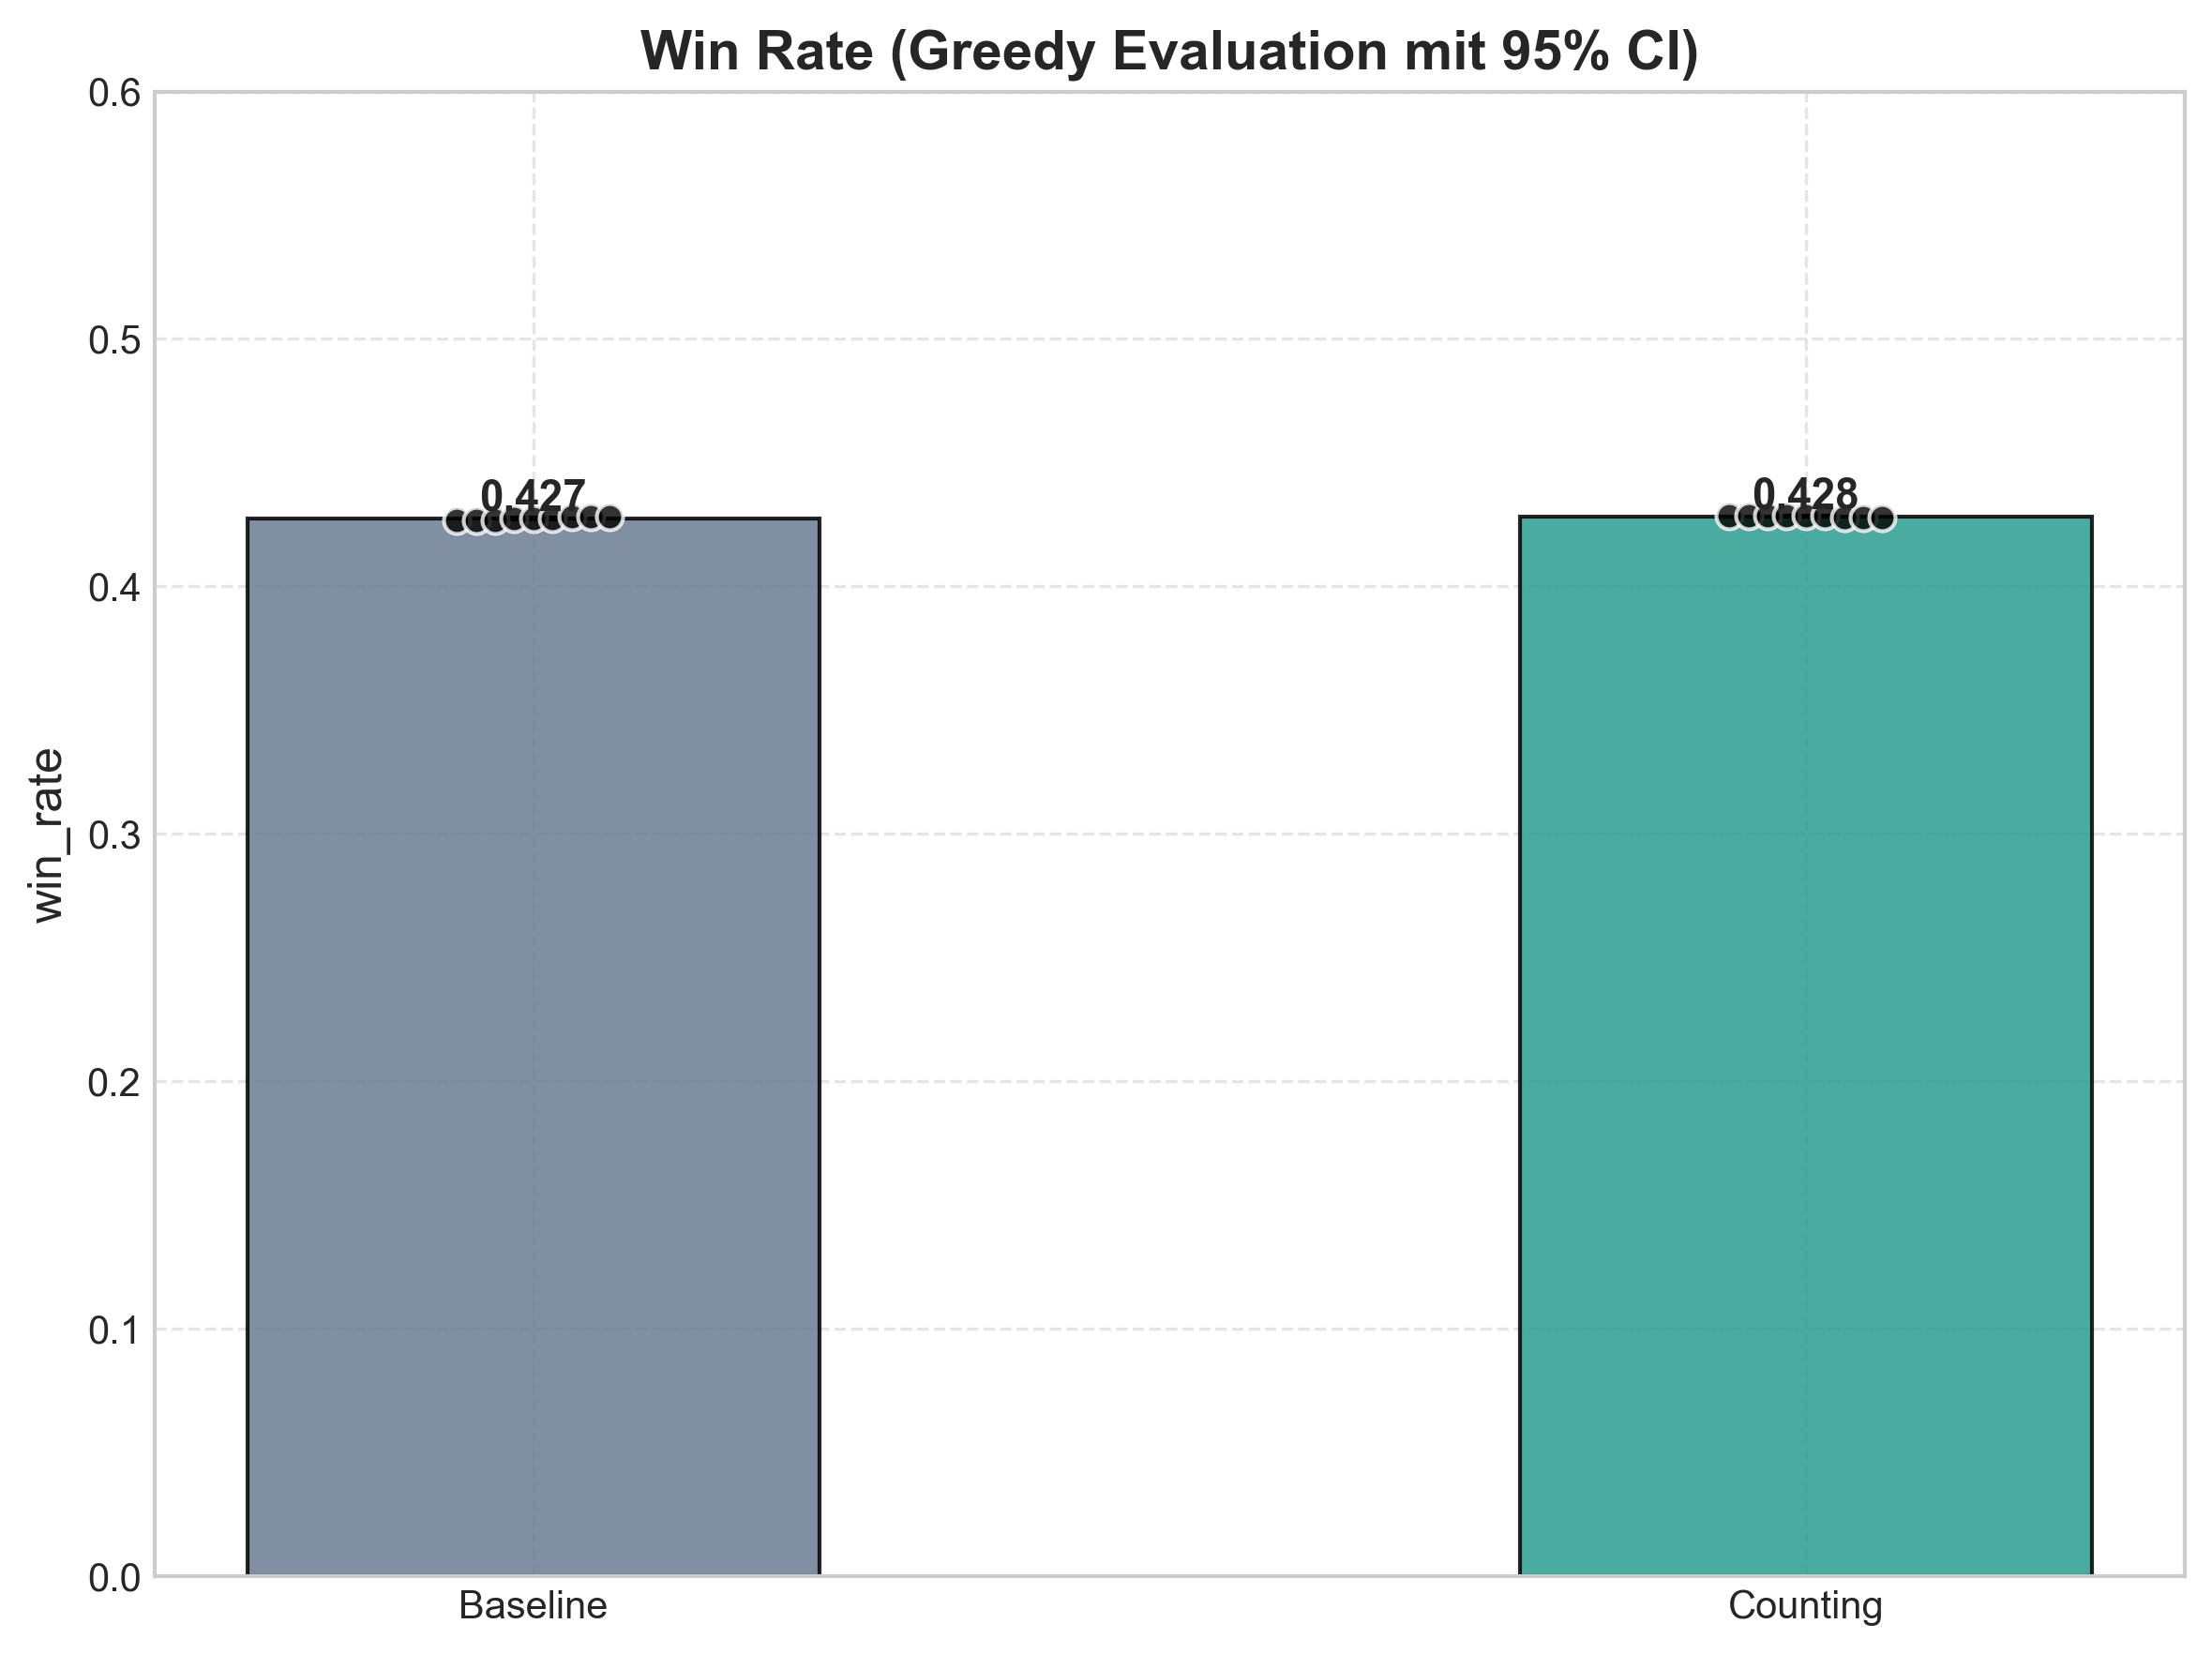

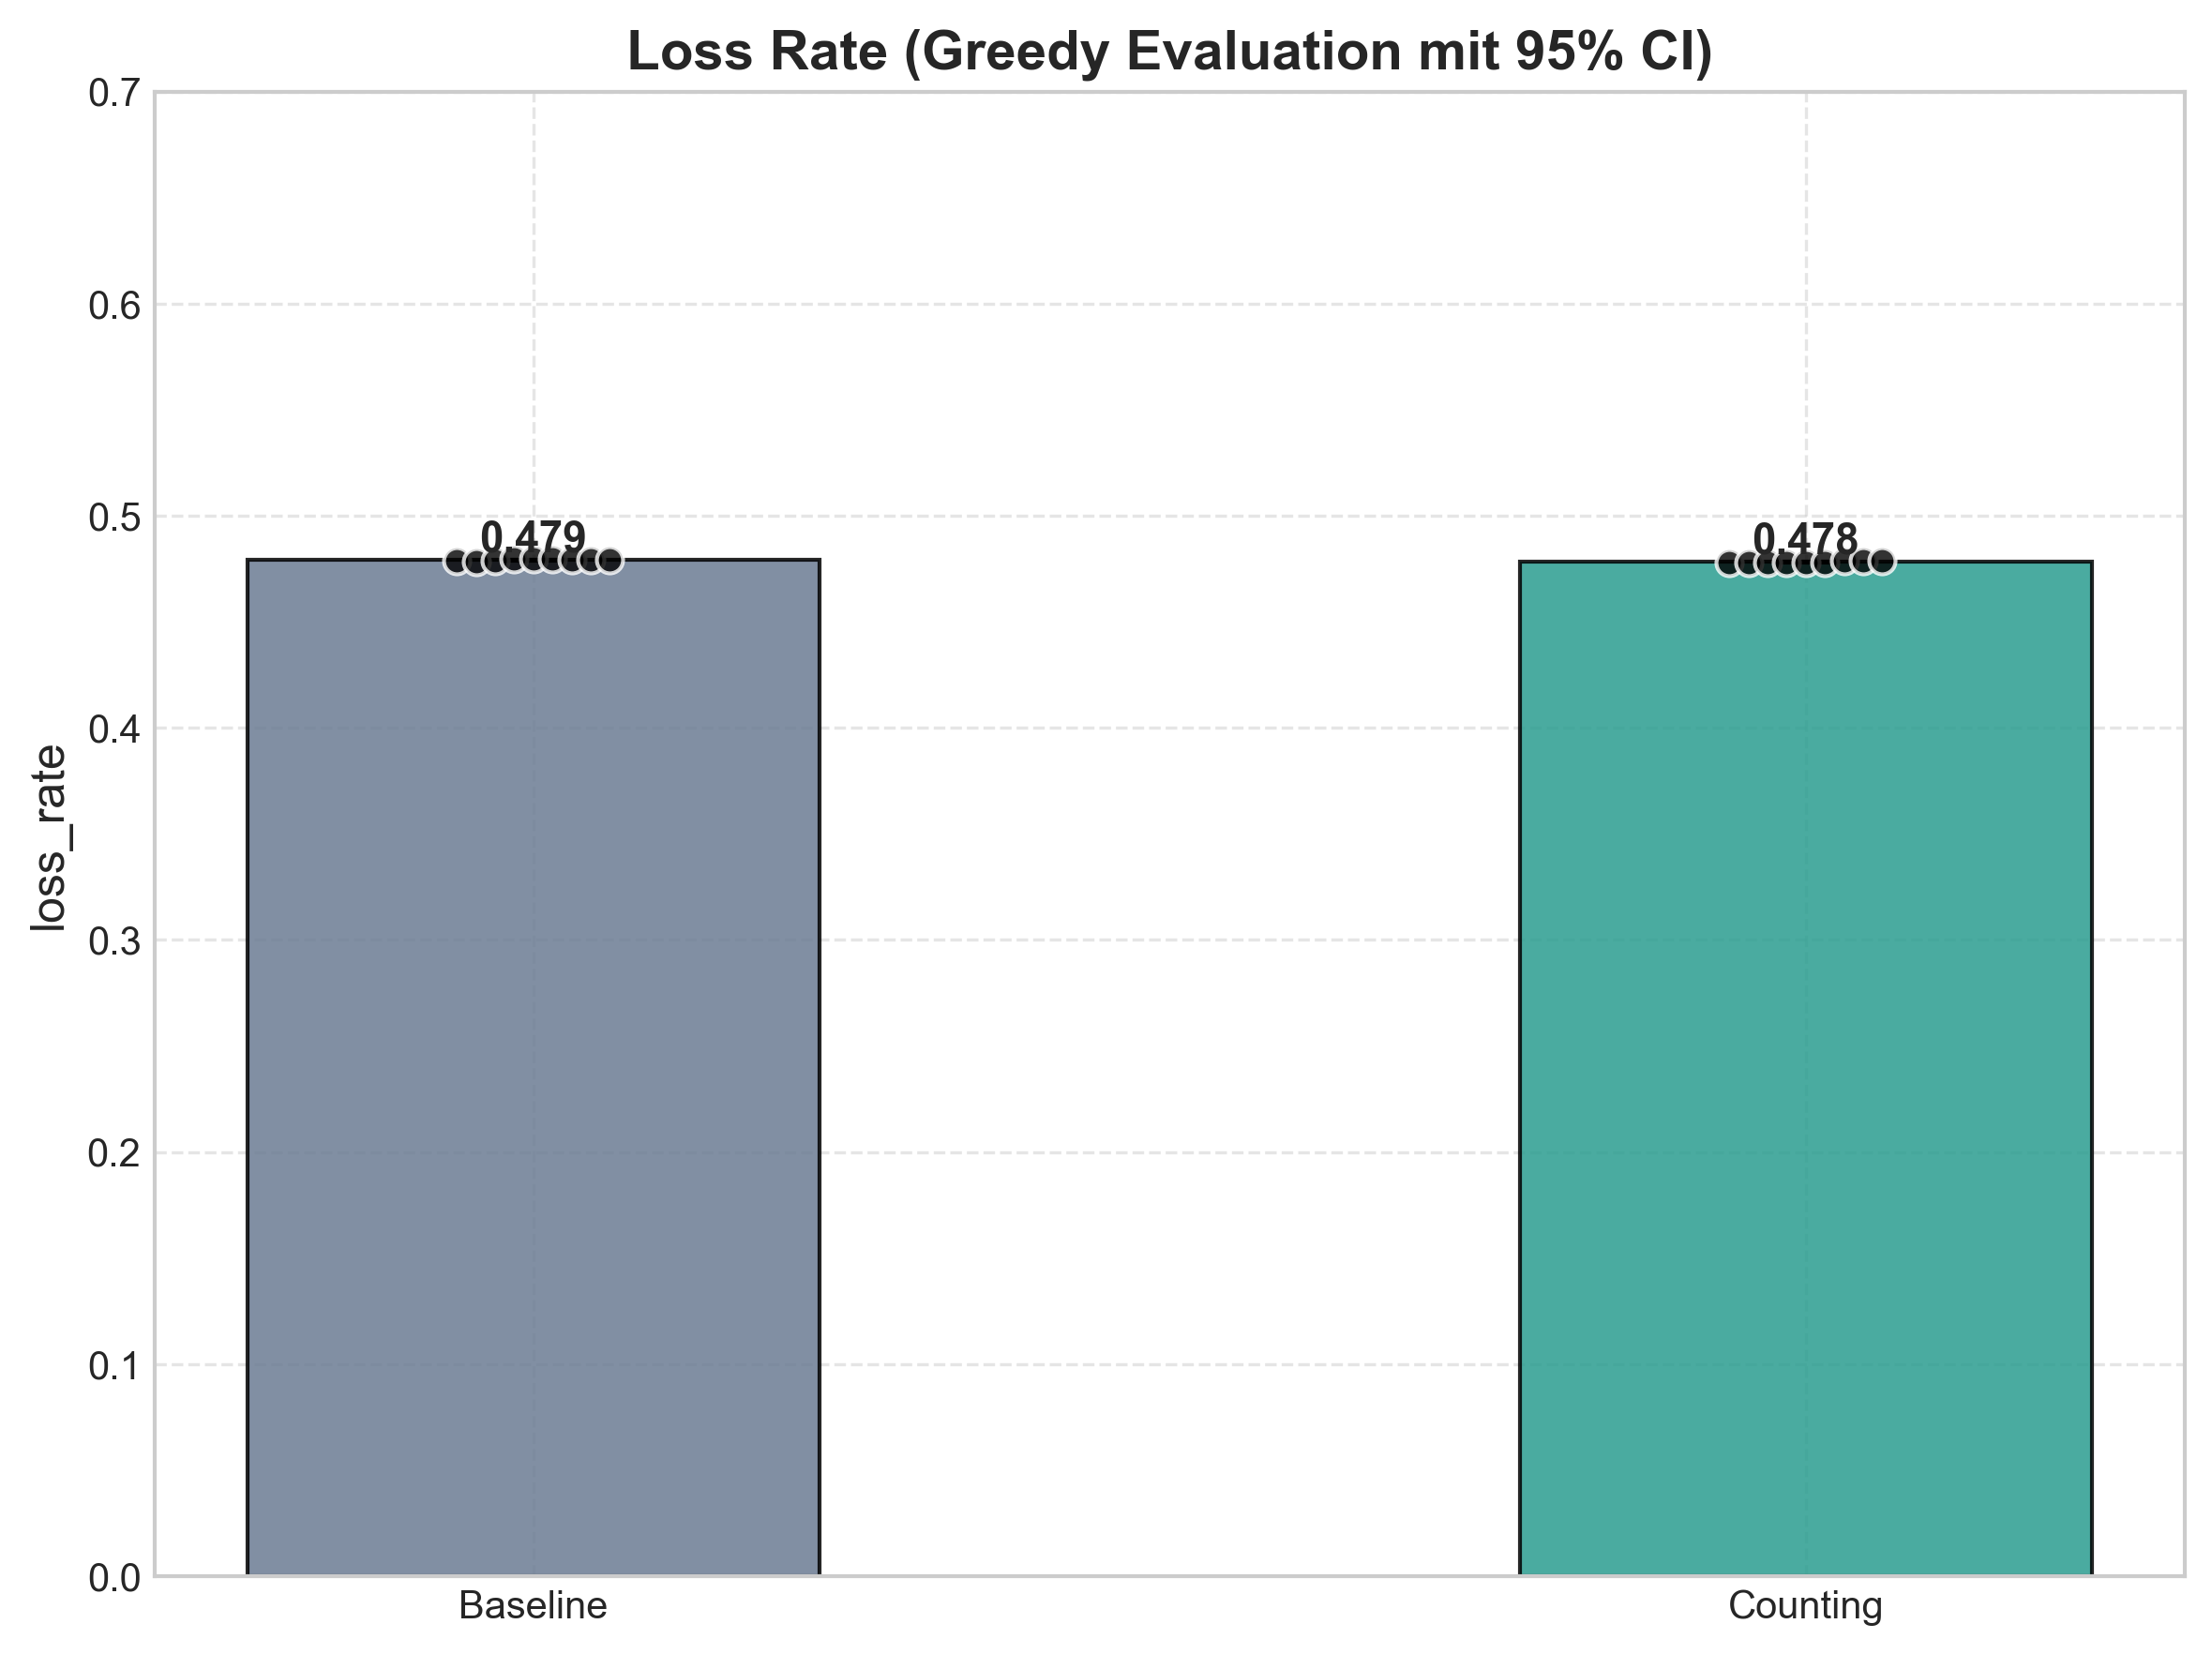

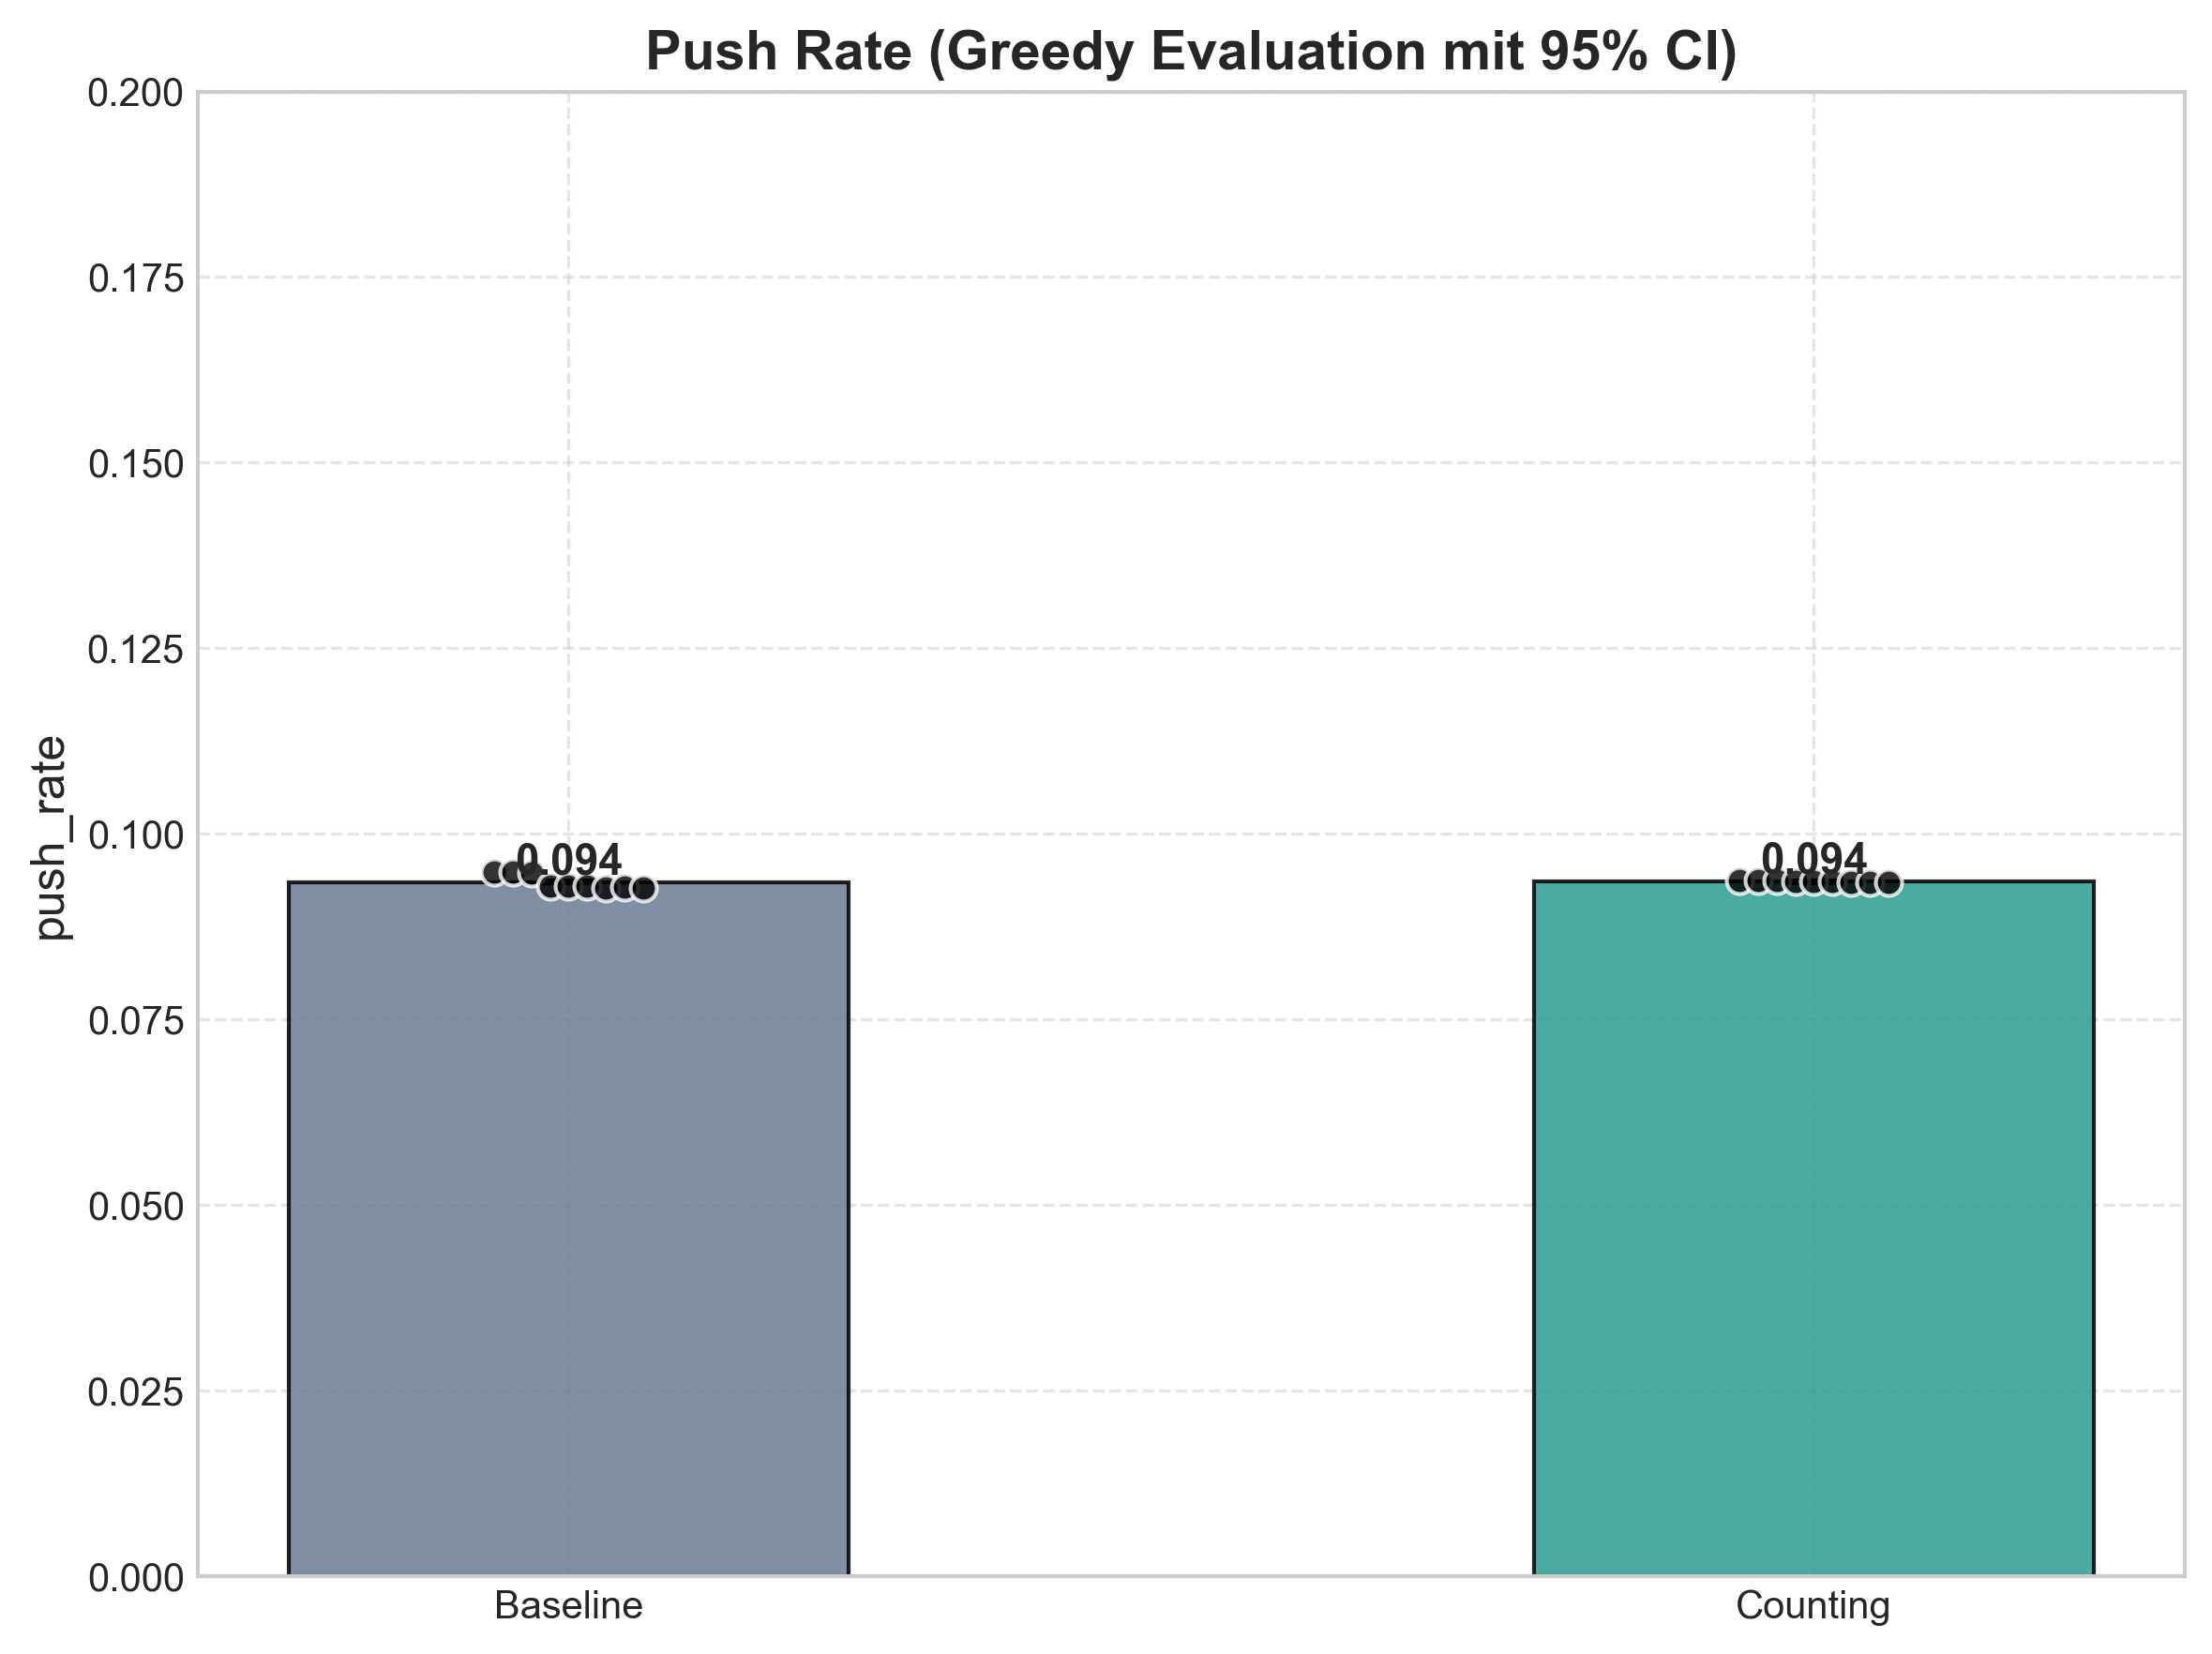

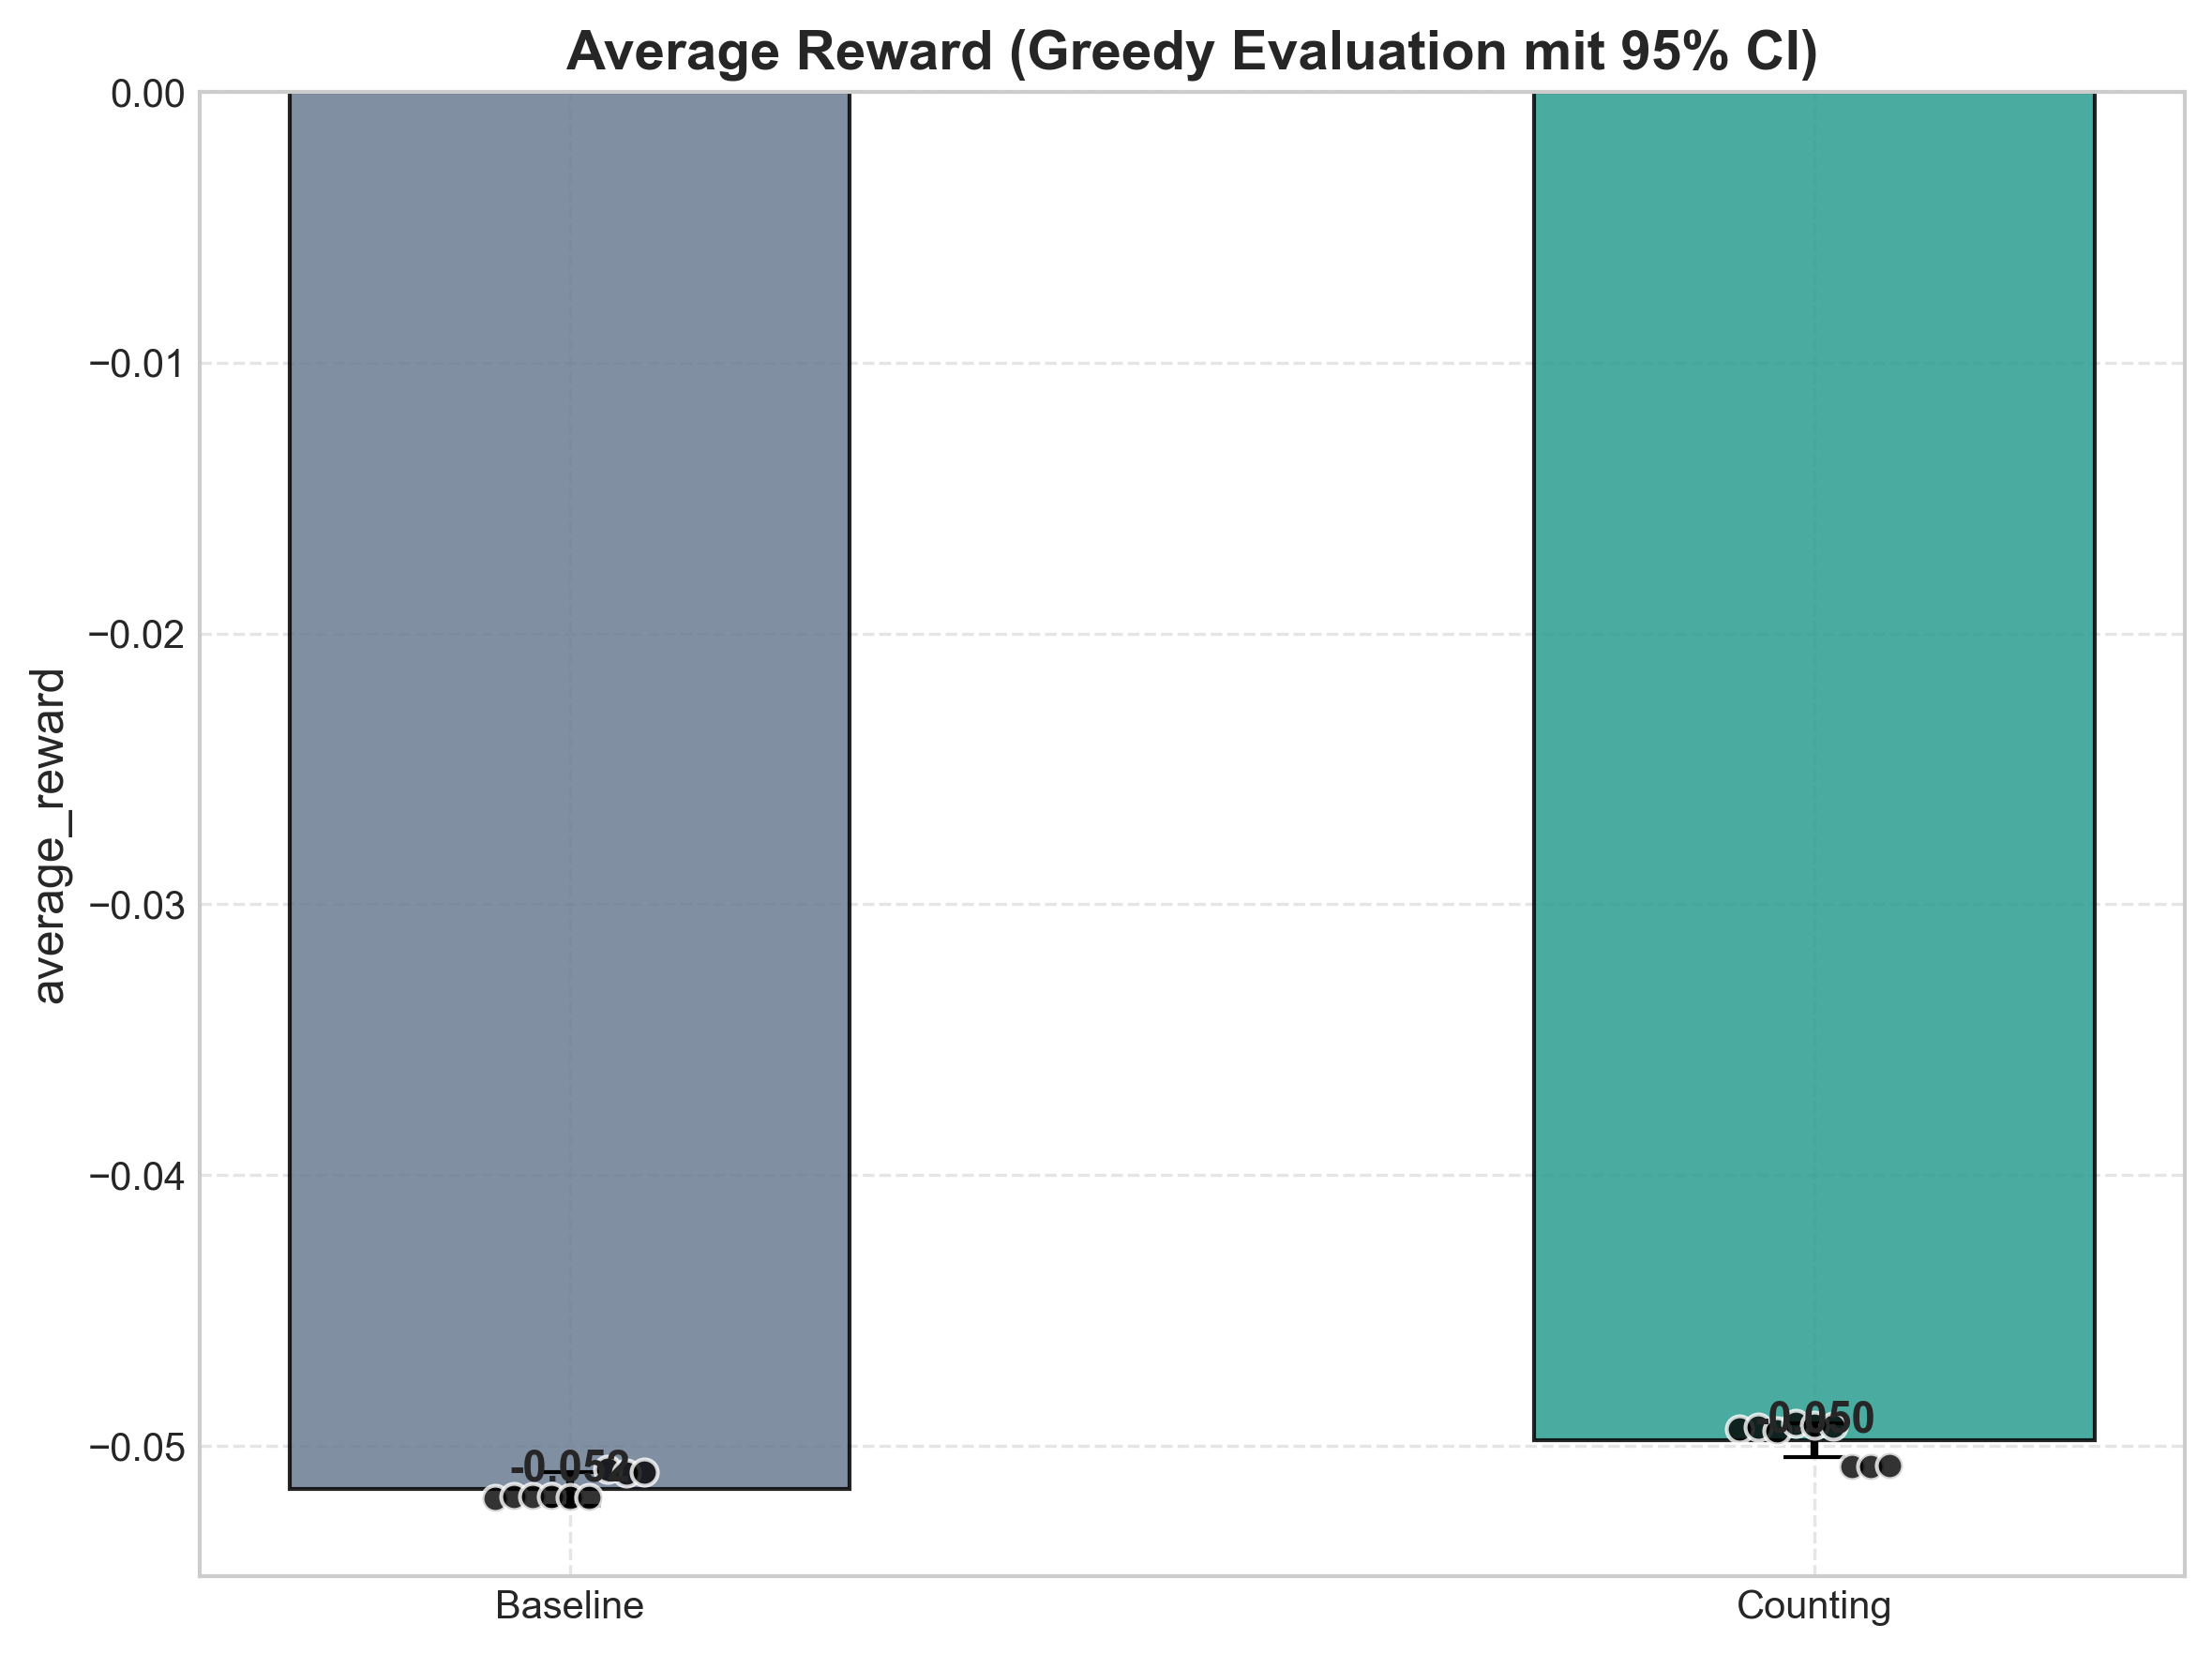

In [10]:
print("\nGeneriere Signifikanz-Plots...")
greedy_eval_plot_df = greedy_eval_data.drop(
    columns=["agent_name", "agent_type", "train_seed", "eval_seed"],
    errors="ignore",
)

evaluation_plot_paths = plot_evaluation_metrics_with_cis(
    greedy_eval_df=greedy_eval_plot_df,
    agent_styles=AGENT_STYLES,
    split_agent_name_func=lambda task_name: split_agent_name(split_eval_task_name(task_name)[0]),
    save_fig_func=save_fig,
)

display_saved_images(
    evaluation_plot_paths.values(),
    title="Greedy Evaluation mit 95% Konfidenzintervallen",
)


# 5. True-Count-Bucket-Auswertung

Die Counting-Effekte werden in vier True-Count-Bereiche aufgeteilt. Alle Kennzahlen werden gespeichert; im Notebook erscheint eine kompakte Auswahl.


In [11]:
TRUE_COUNT_BUCKETS = [
    ("<= -3", None, -3),
    ("-2 to 0", -2, 0),
    ("1 to 2", 1, 2),
    (">= 3", 3, None),
]

In [12]:
require_eval_artifacts()

bucket_tasks, bucket_agent_names = build_true_count_bucket_tasks(
    agents=agents,
    selected_eval_agent_func=selected_eval_agent,
    split_agent_name_func=split_agent_name,
    eval_task_name_func=eval_task_name,
    baseline_state_key_func=baseline_state_key,
    counting_state_key_func=counting_state_key,
    eval_seeds=EVAL_SEEDS,
    eval_episodes=EVAL_EPISODES,
    buckets=TRUE_COUNT_BUCKETS,
)

bucket_results = run_parallel_with_dashboard(
    worker_func=evaluate_true_count_buckets_parallel,
    base_tasks=bucket_tasks,
    agent_names=bucket_agent_names,
    max_value_per_agent=EVAL_EPISODES,
    title="True-Count-Bucket-Evaluation",
)

(
    true_count_bucket_raw_df,
    true_count_bucket_summary_df,
    true_count_bucket_seed_df,
) = prepare_true_count_bucket_reports(
    bucket_results=bucket_results,
    split_eval_task_name_func=split_eval_task_name,
    split_agent_name_func=split_agent_name,
    evaluation_dir=get_evaluation_dir(),
)

Initialisiere paralleles True-Count-Bucket-Evaluation-Dashboard...



Prozess erfolgreich beendet! Gesamtdauer: 0:05:50


## 5.1 Ergebnisse und Bucket-Plots


True-Count-Bucket-Auswertung gespeichert unter: E:\tomni\Documents\01_Code\ml-blackjack\models\evaluations\20260610_164317


,aggregation,comparison_id,bucket,episodes,average_reward,win_rate,loss_rate,push_rate,hit_rate,stand_rate
0,mean,baseline (all seeds),<= -3,826998,-0.027942,0.436443,0.464385,0.099172,0.462370,0.537630
1,mean,baseline (all seeds),-2 to 0,5726933,-0.048461,0.428144,0.476605,0.095251,0.475788,0.524212
2,mean,baseline (all seeds),1 to 2,1653001,-0.066687,0.422700,0.489386,0.087914,0.494675,0.505325
3,mean,baseline (all seeds),>= 3,793068,-0.067142,0.422986,0.490128,0.086885,0.493598,0.506402
4,mean,counting (all seeds),<= -3,832289,-0.031670,0.433214,0.464884,0.101902,0.486251,0.513749
5,mean,counting (all seeds),-2 to 0,5723838,-0.046412,0.428956,0.475368,0.095677,0.478056,0.521944
6,mean,counting (all seeds),1 to 2,1649631,-0.063749,0.424547,0.488295,0.087158,0.478542,0.521458
7,mean,counting (all seeds),>= 3,794242,-0.063668,0.426665,0.490333,0.083002,0.445861,0.554139
8,median,baseline (all seeds),<= -3,826998,-0.028710,0.435380,0.464090,0.098554,0.462814,0.537186
9,median,baseline (all seeds),-2 to 0,5726933,-0.048232,0.427899,0.476718,0.094886,0.475106,0.524894


Generiere Plots fuer Aggregations-Typ: 'mean'
Verglichene Agenten/Checkpoints: ['baseline (all seeds)', 'counting (all seeds)']
--------------------------------------------------


### True-Count-Bucket-Auswertung (Auswahl)

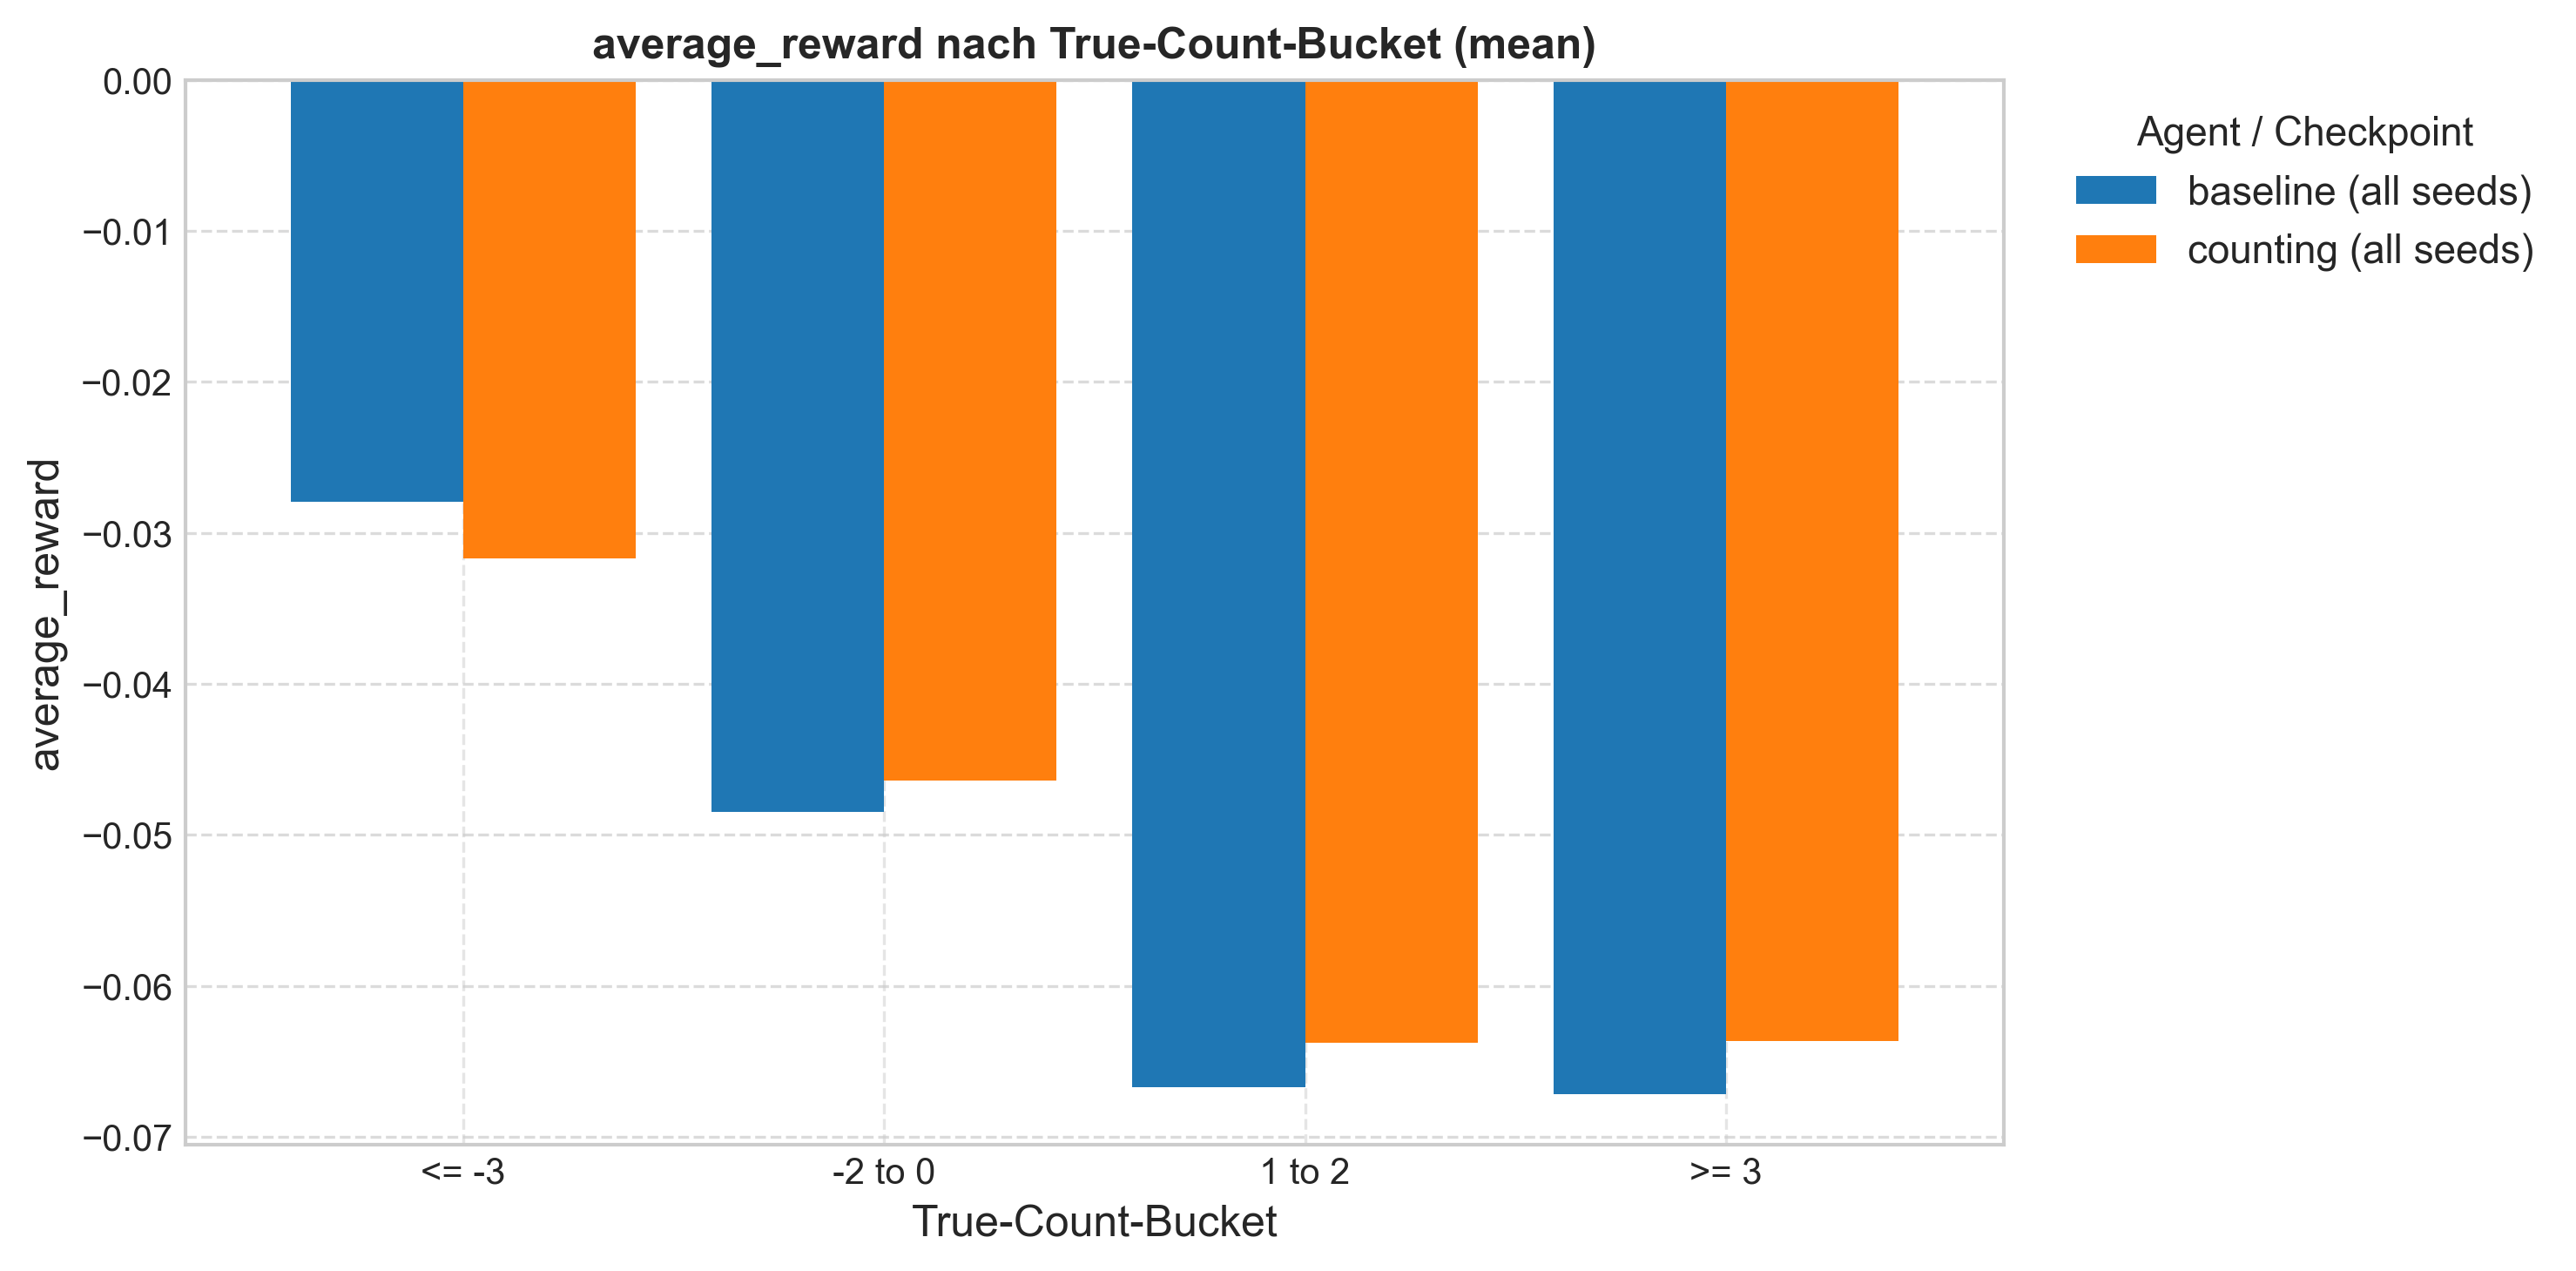

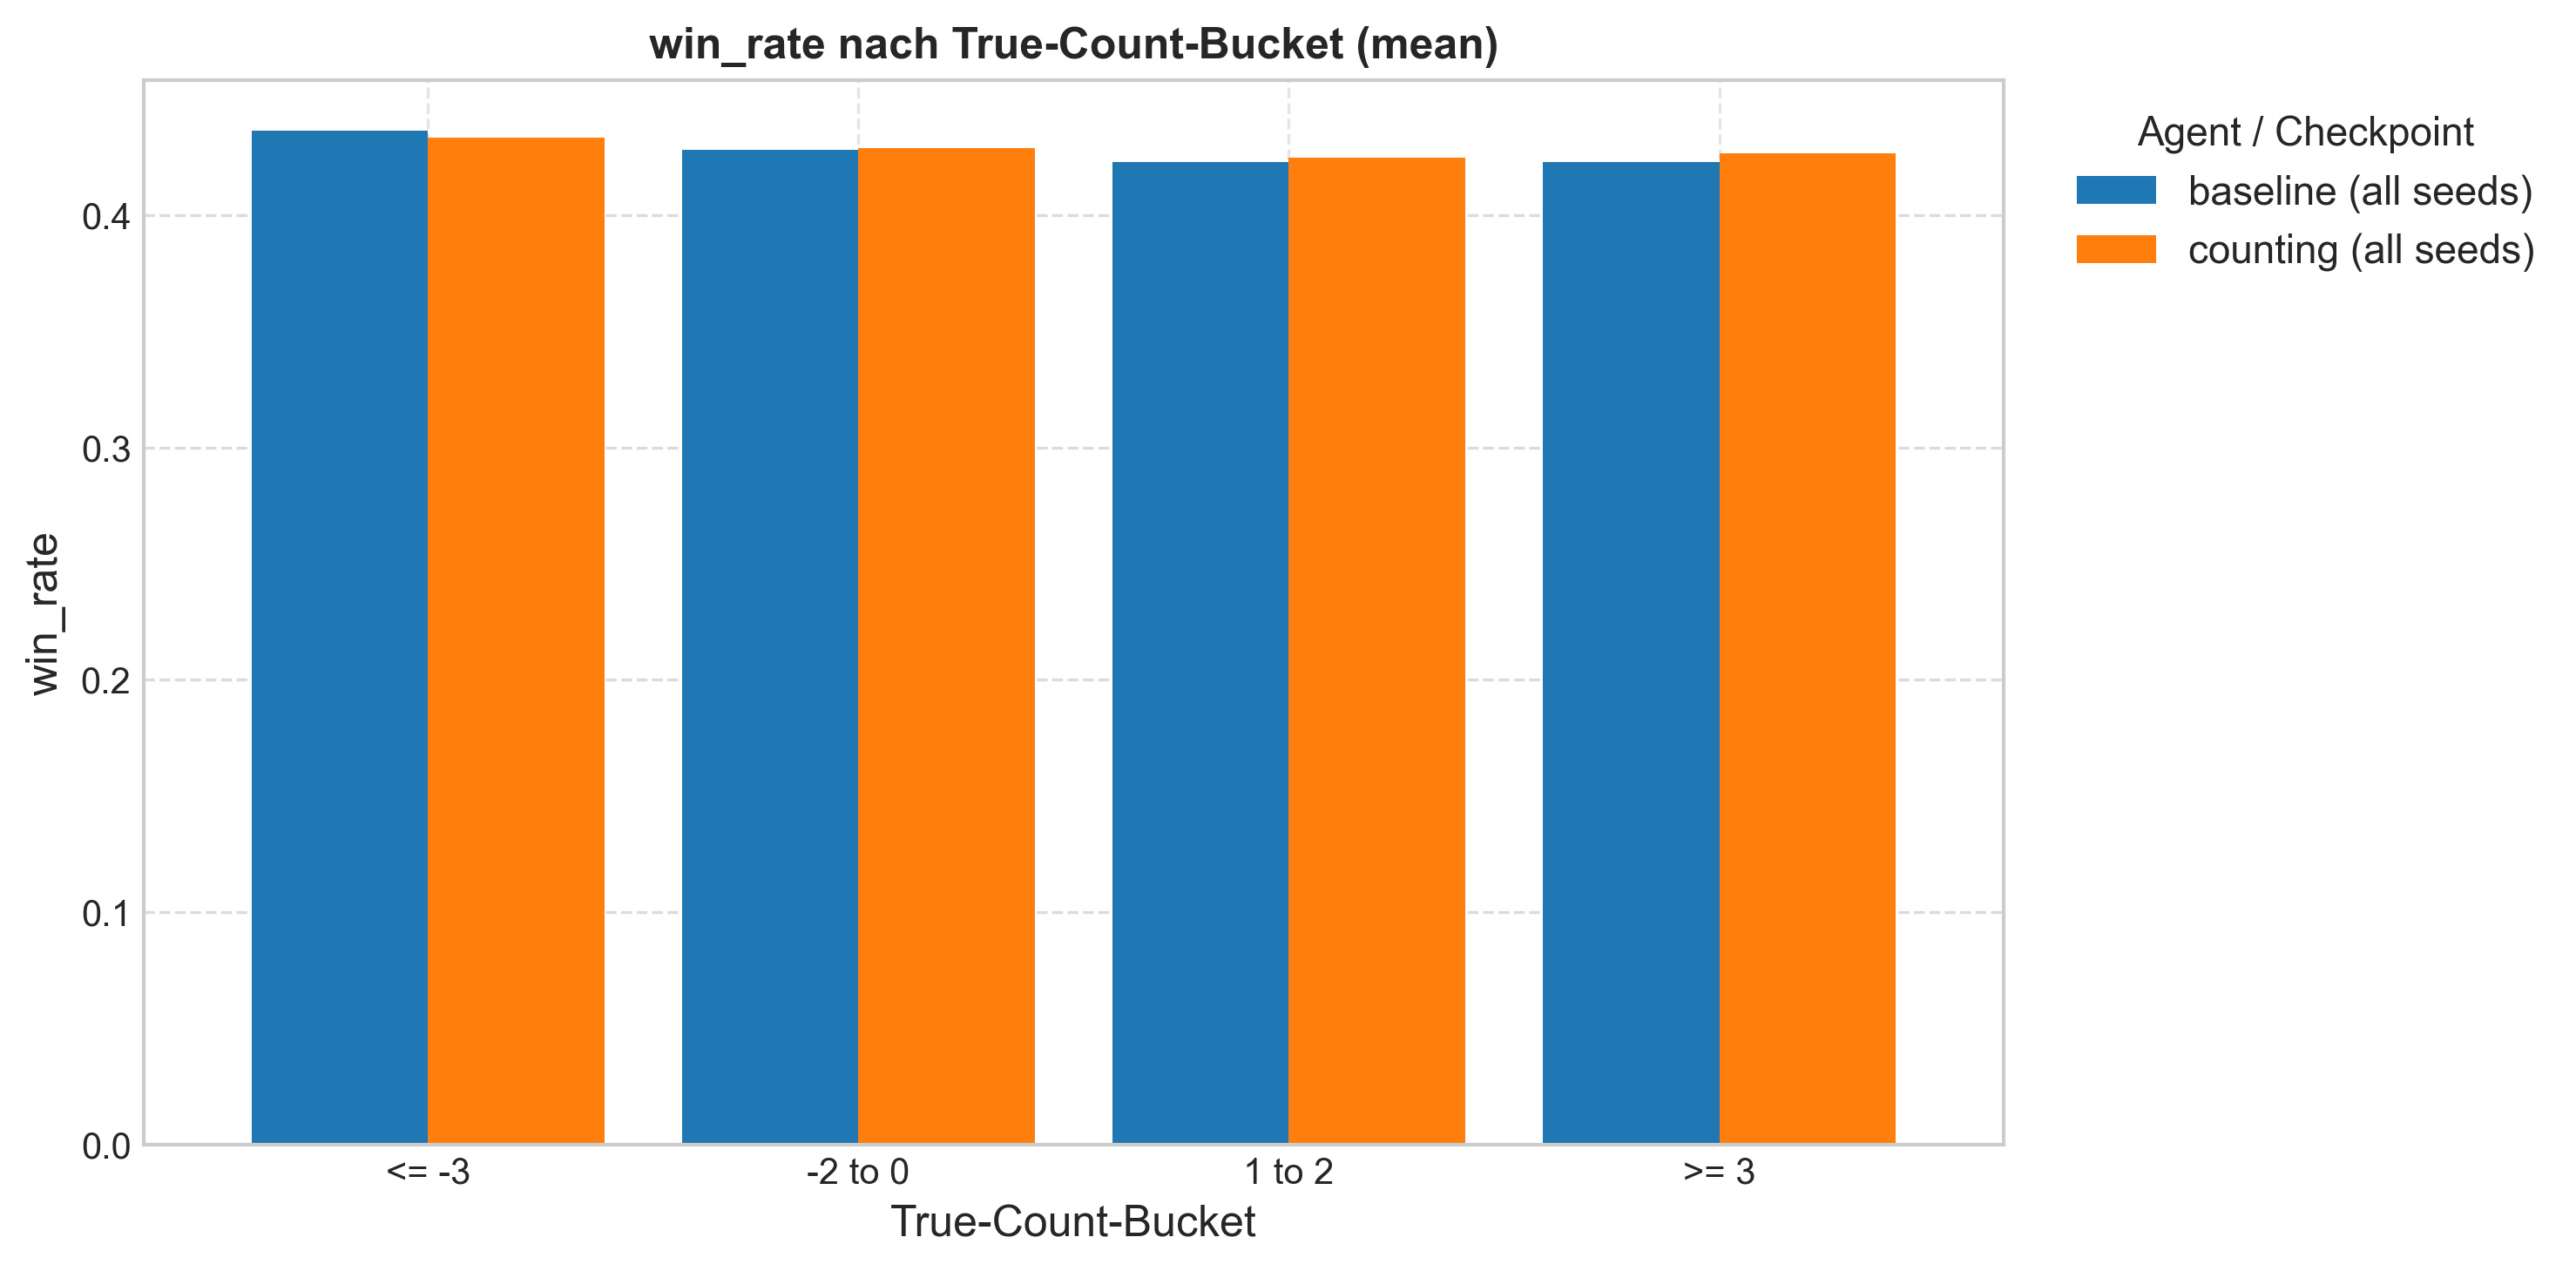

In [13]:
evaluation_dir = get_evaluation_dir()

print(f"True-Count-Bucket-Auswertung gespeichert unter: {evaluation_dir}")

display(
    true_count_bucket_summary_df[
        TRUE_COUNT_BUCKET_SUMMARY_COLUMNS
    ]
)

bucket_plot_results = plot_all_true_count_bucket_metrics(
    summary_df=true_count_bucket_summary_df,
    seed_df=true_count_bucket_seed_df,
    buckets=TRUE_COUNT_BUCKETS,
    aggregation="mean",
    save_fig_func=save_fig,
)

bucket_preview_paths = [
    bucket_plot_results[metric]["path"]
    for metric in ("average_reward", "win_rate")
]
display_saved_images(
    bucket_preview_paths,
    title="True-Count-Bucket-Auswertung (Auswahl)",
)


# 6. Policy- und Q-Value-Analyse

Die quantitative Evaluation nutzt weiterhin **alle Seeds**. Für die bildintensive qualitative Analyse wird Seed **42** als reproduzierbare Referenz verwendet.

Gespeichert werden sechs Analysearten für Baseline sowie für Counting bei True Count `-3`, `0` und `3`. Dadurch entstehen **24 einzelne Dateien statt 72**. Im Notebook werden vier repräsentative Bilder angezeigt.


Policy-Modell für baseline-42: 20260608_170145_baseline-42_agent
Policy-Modell für counting-42: 20260608_170145_counting-42_agent


### Policy- und Q-Value-Analyse (Seed 42, kompakte Auswahl)

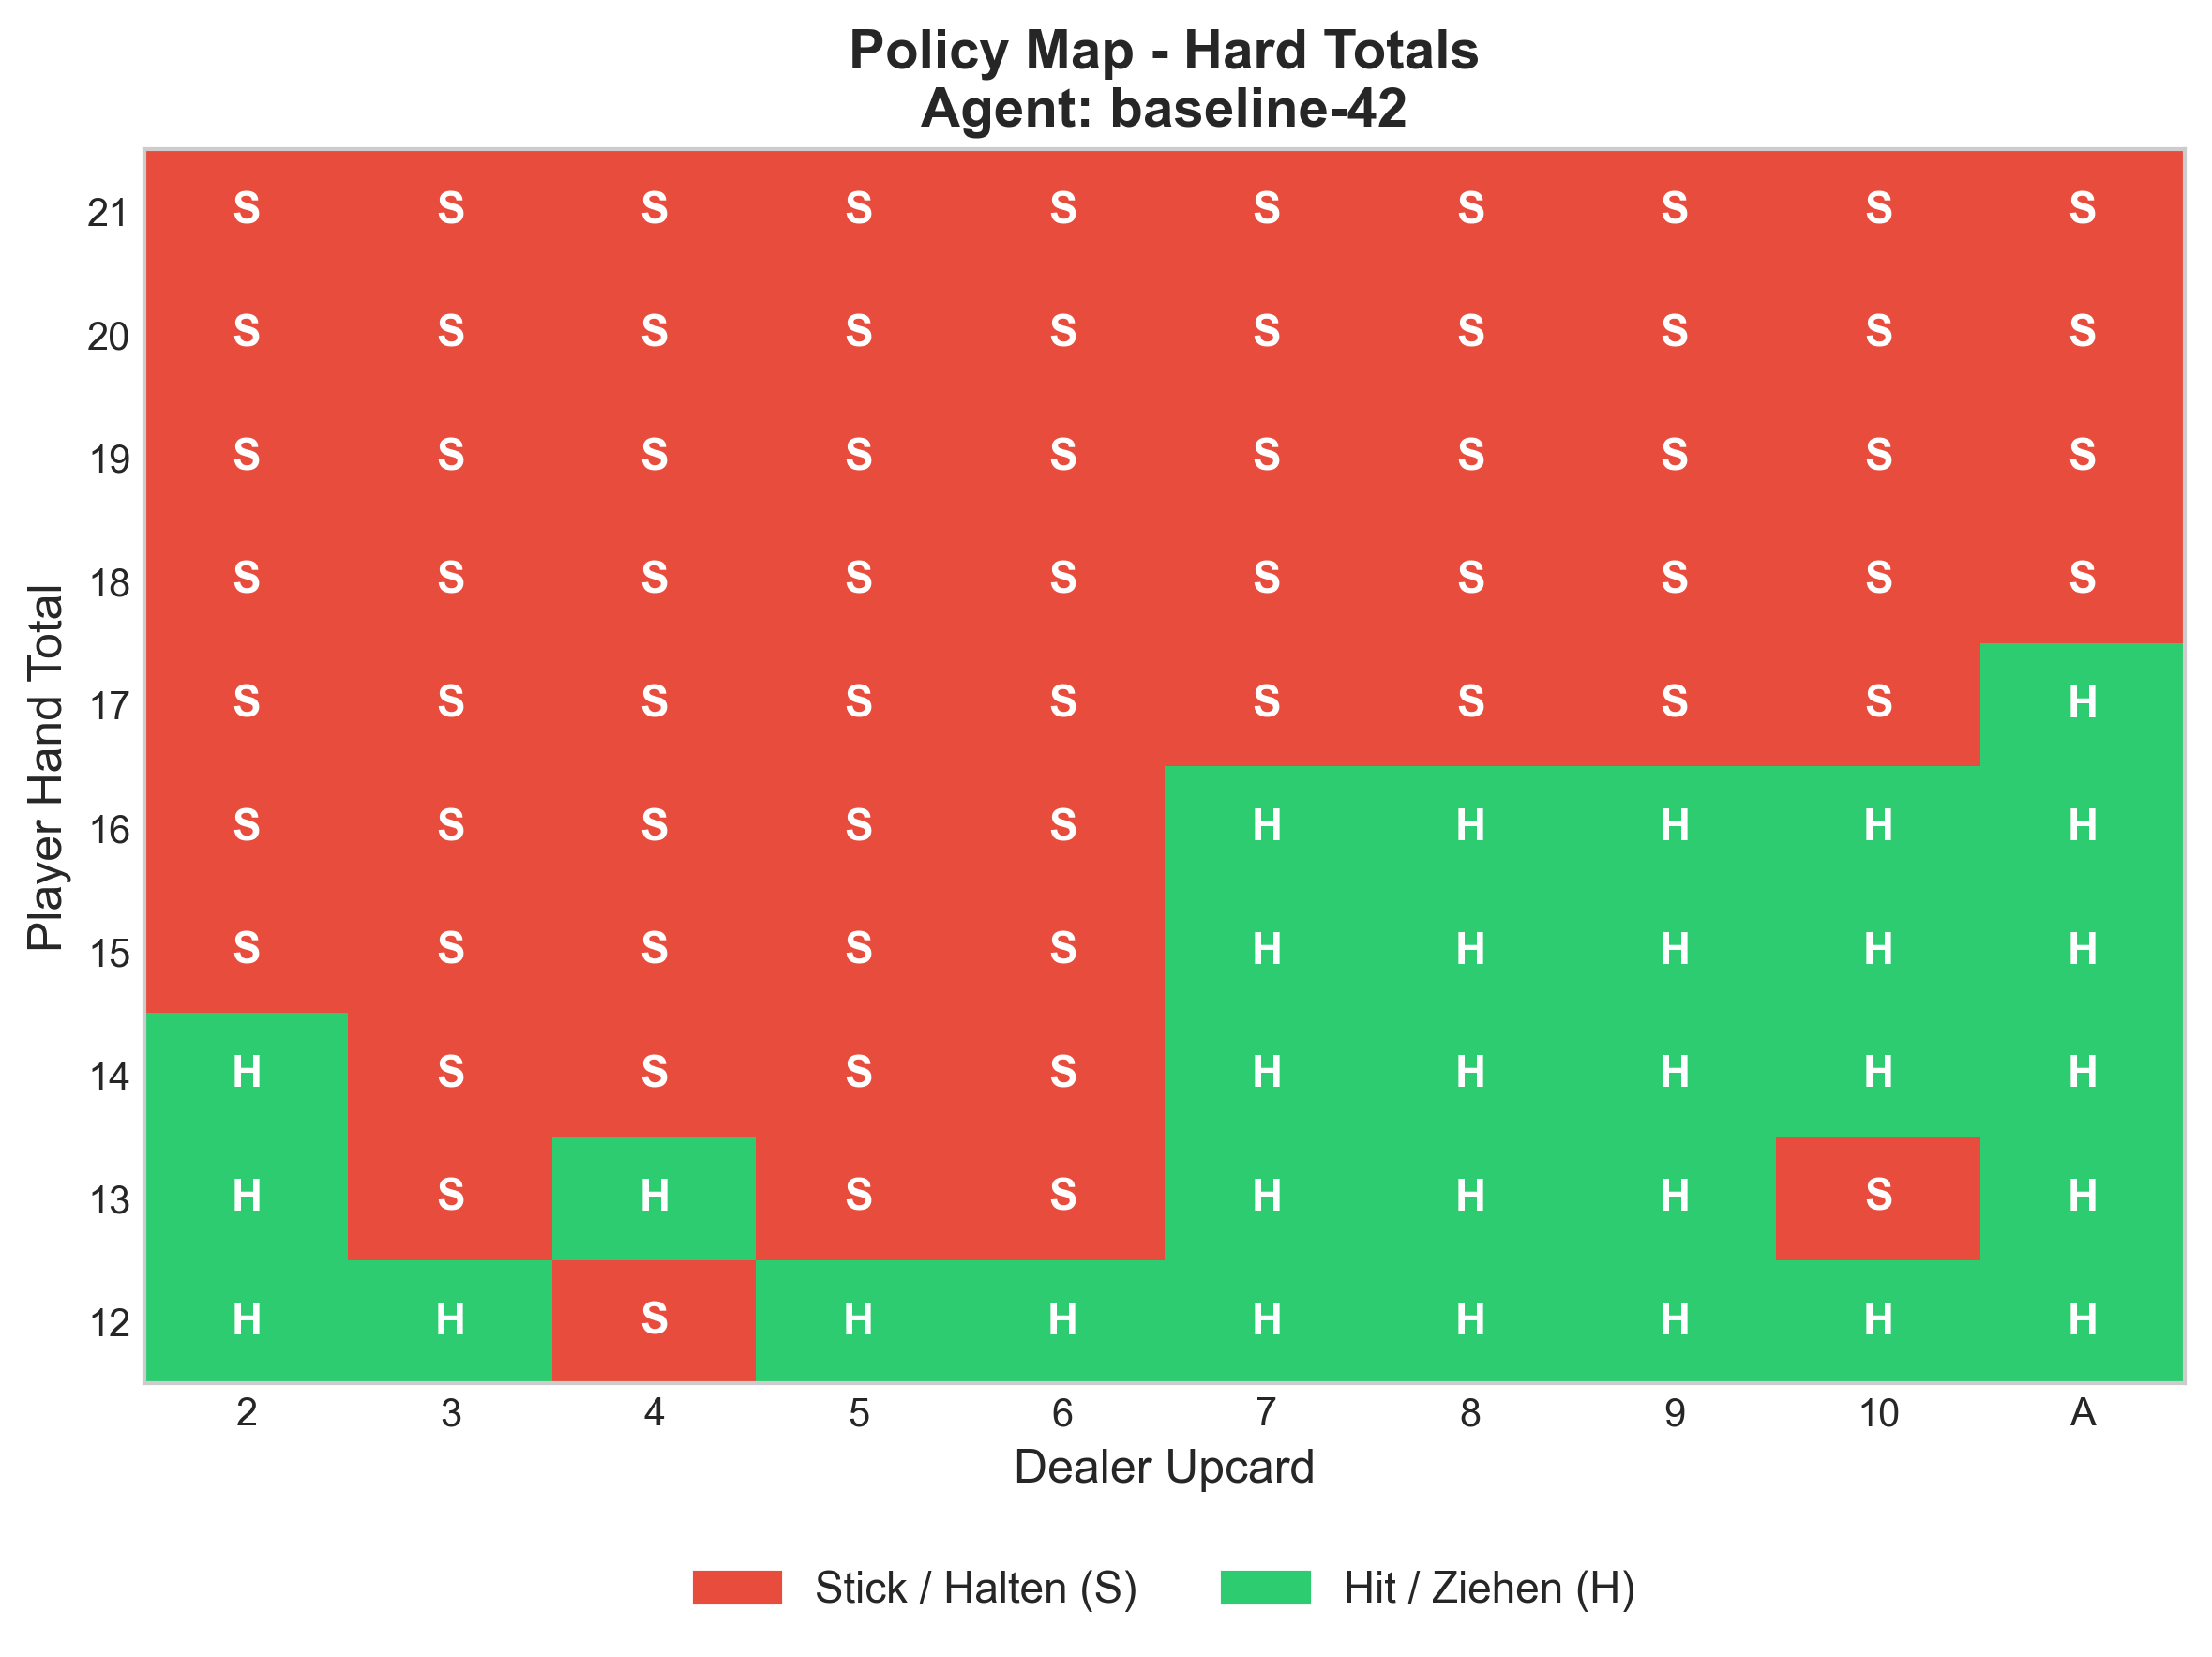

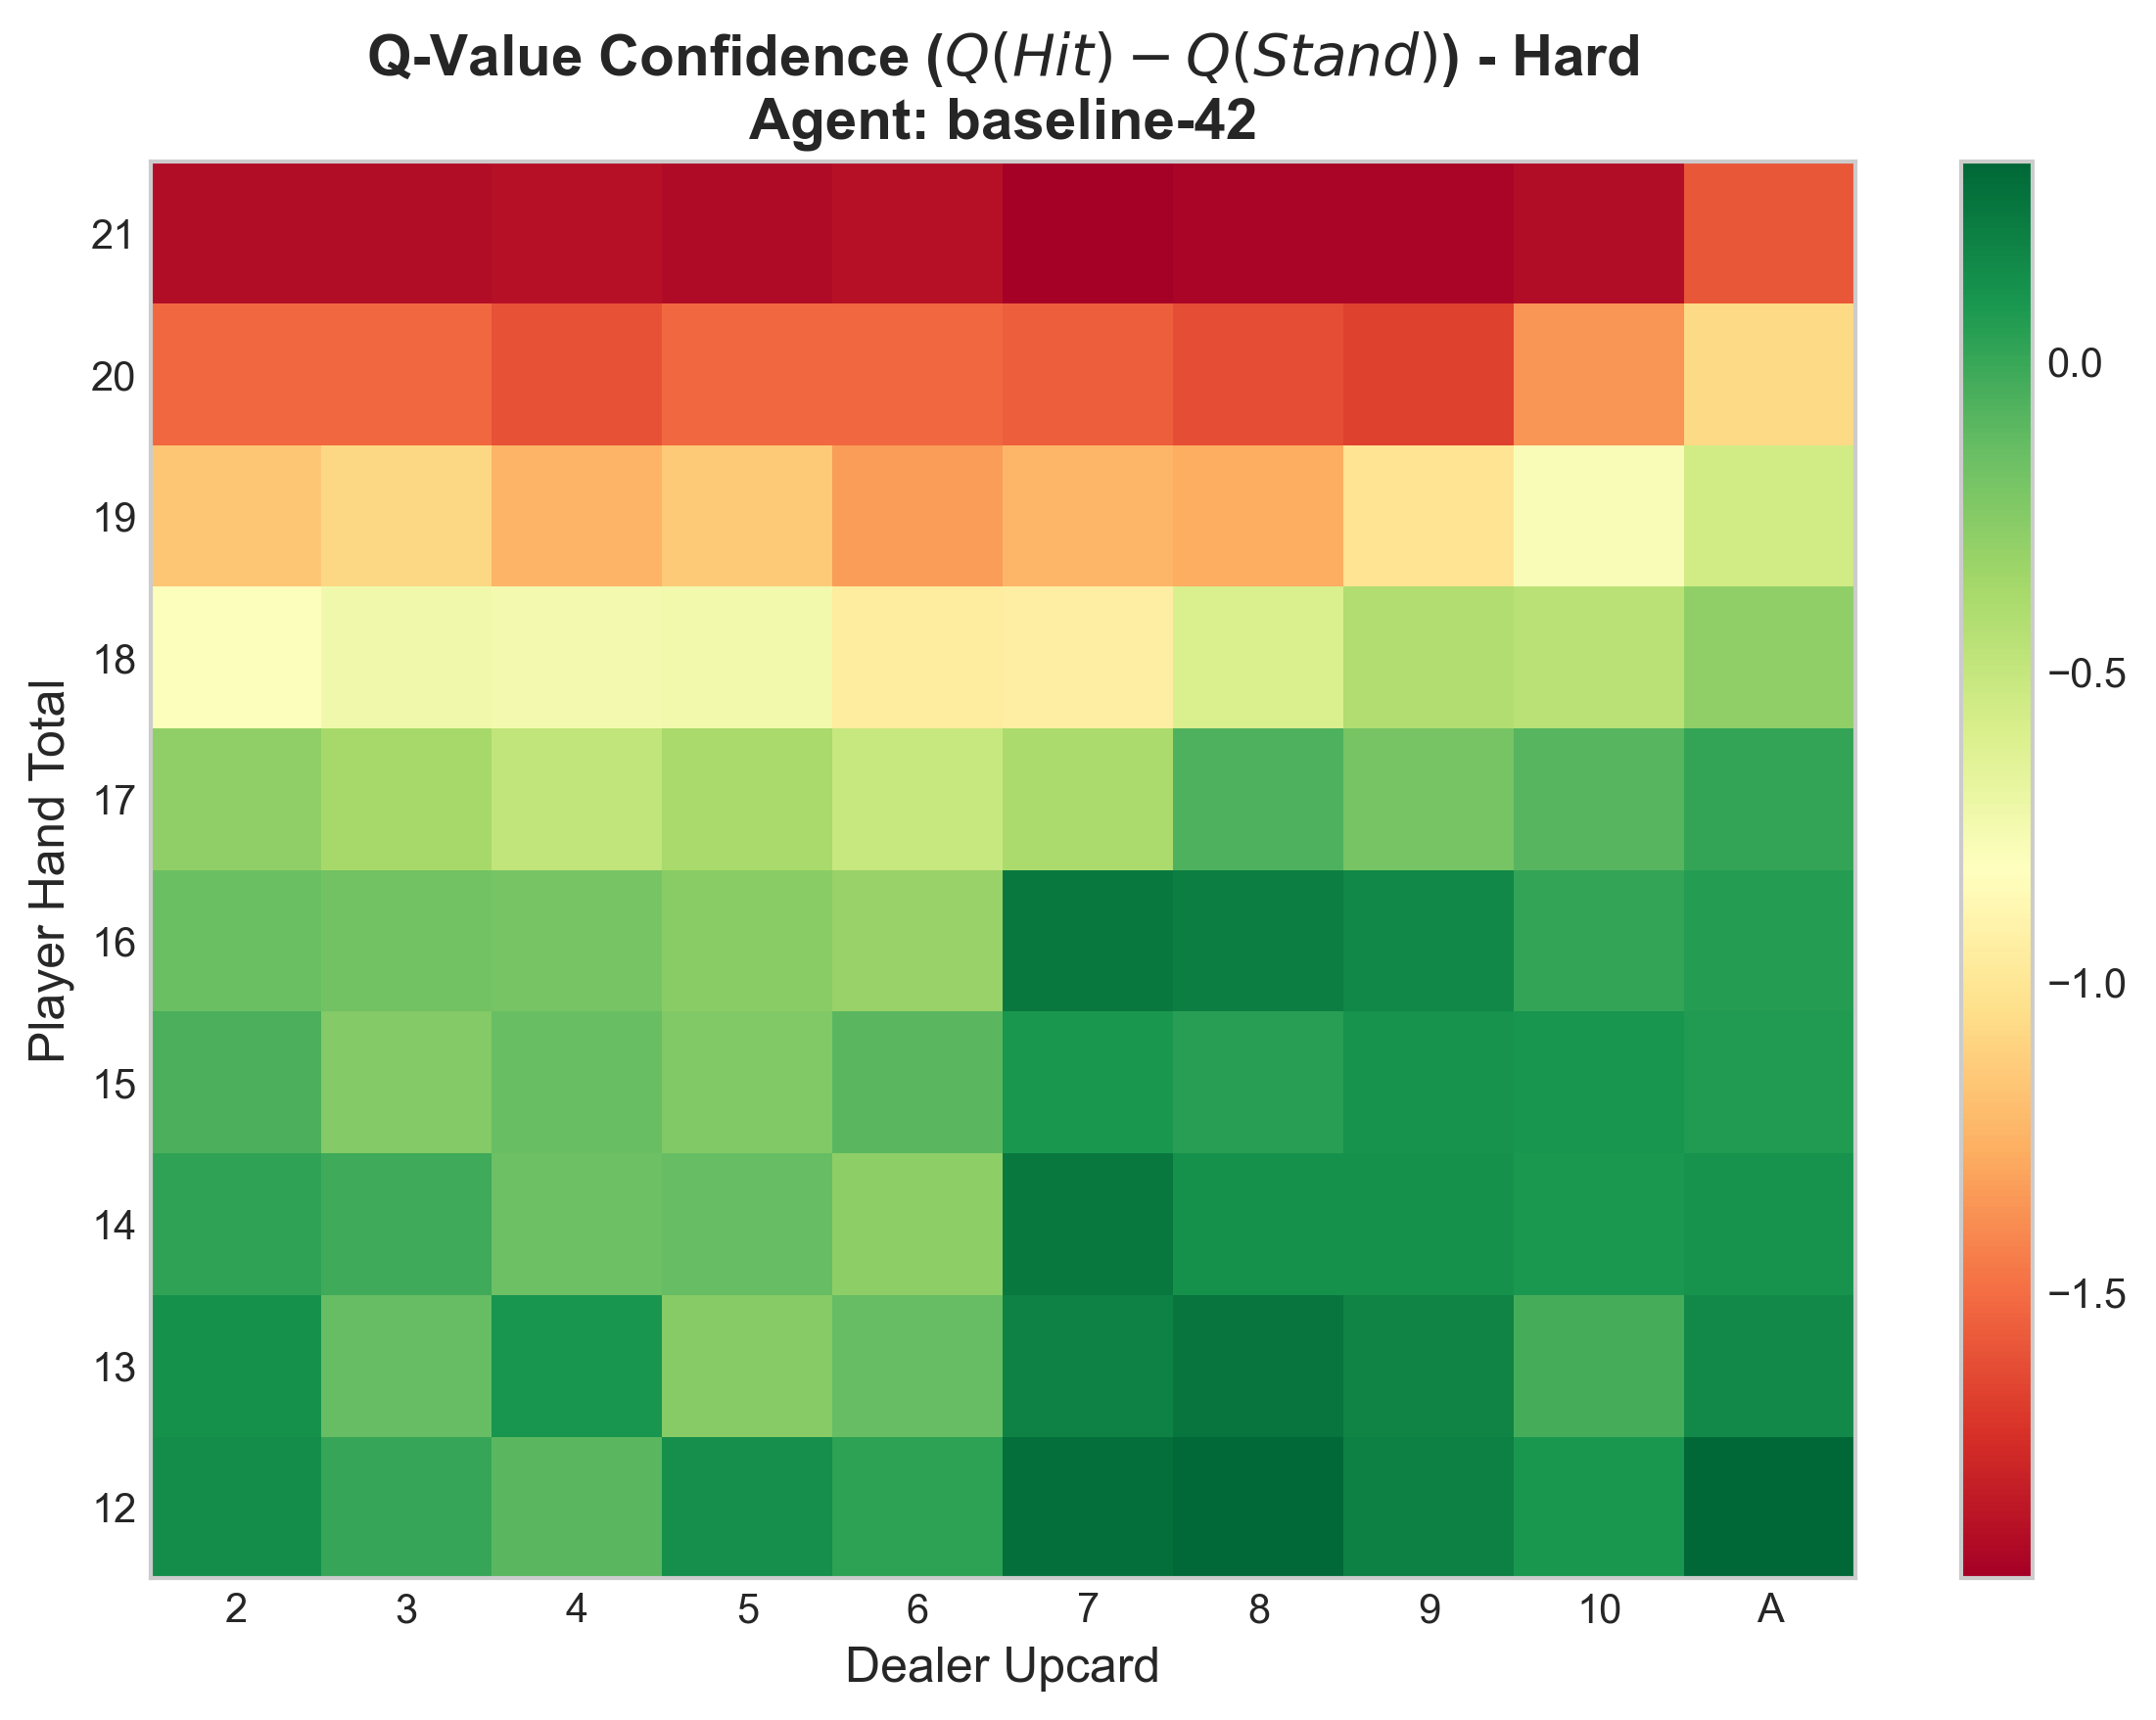

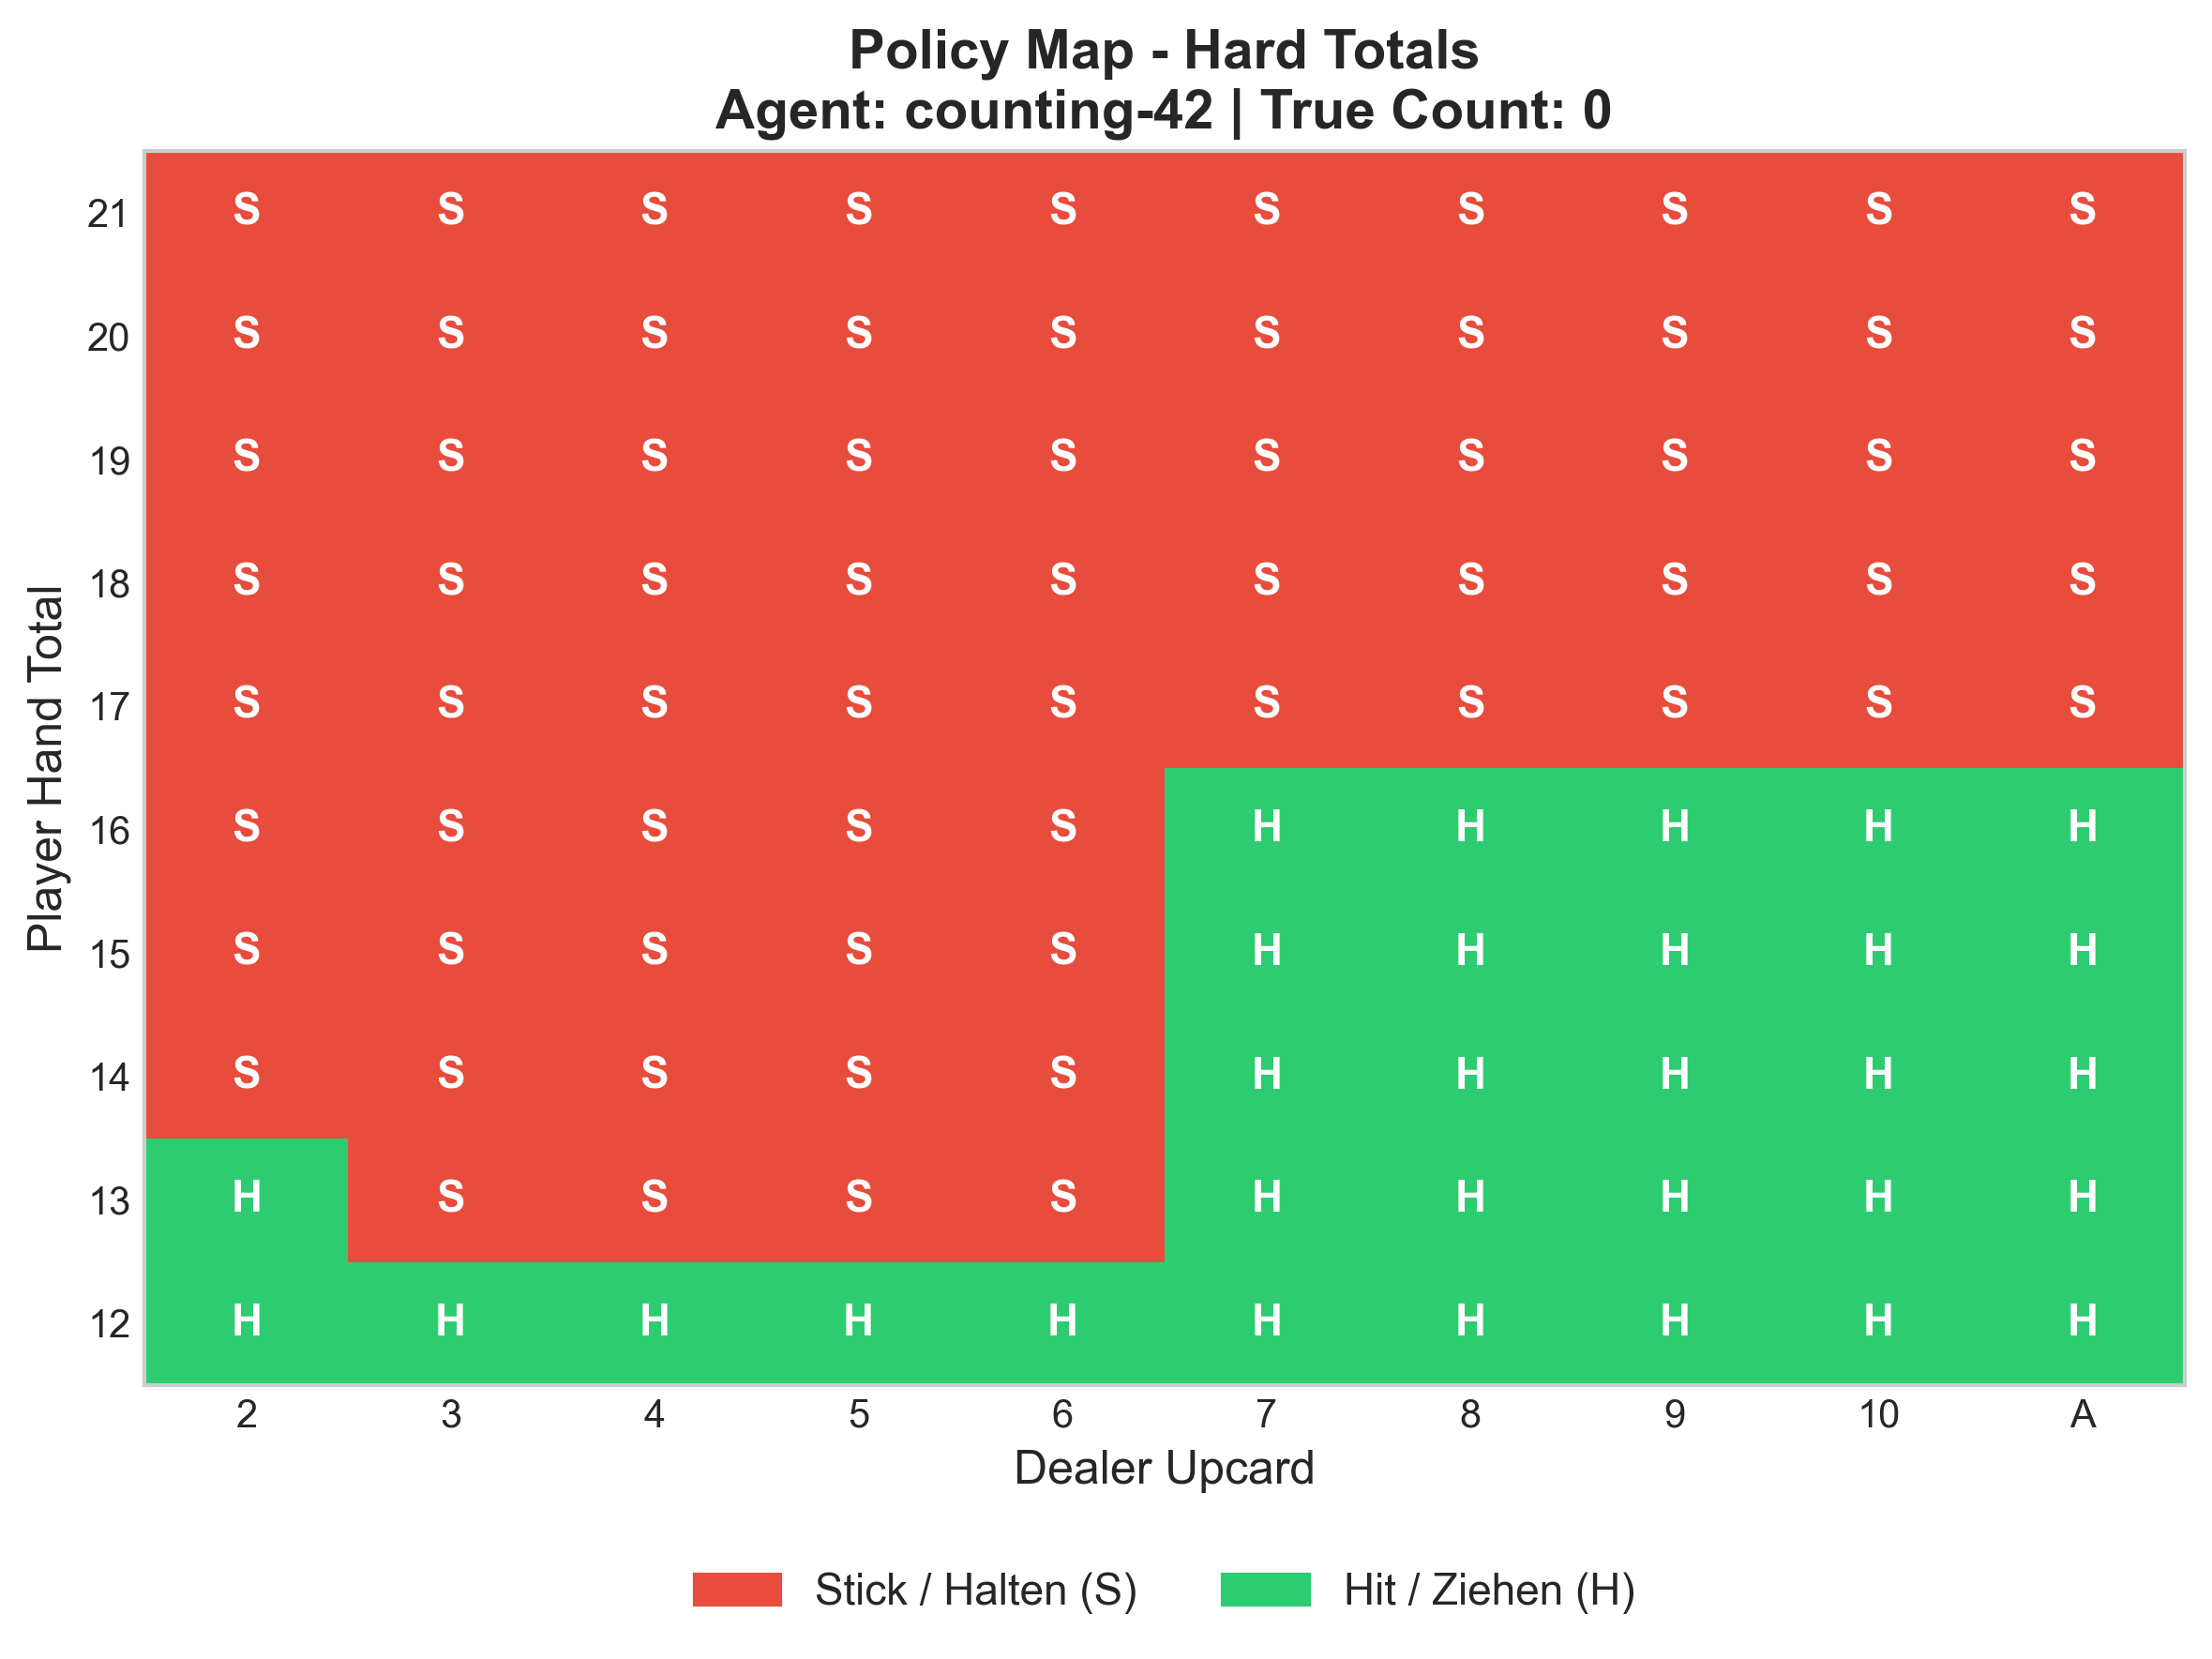

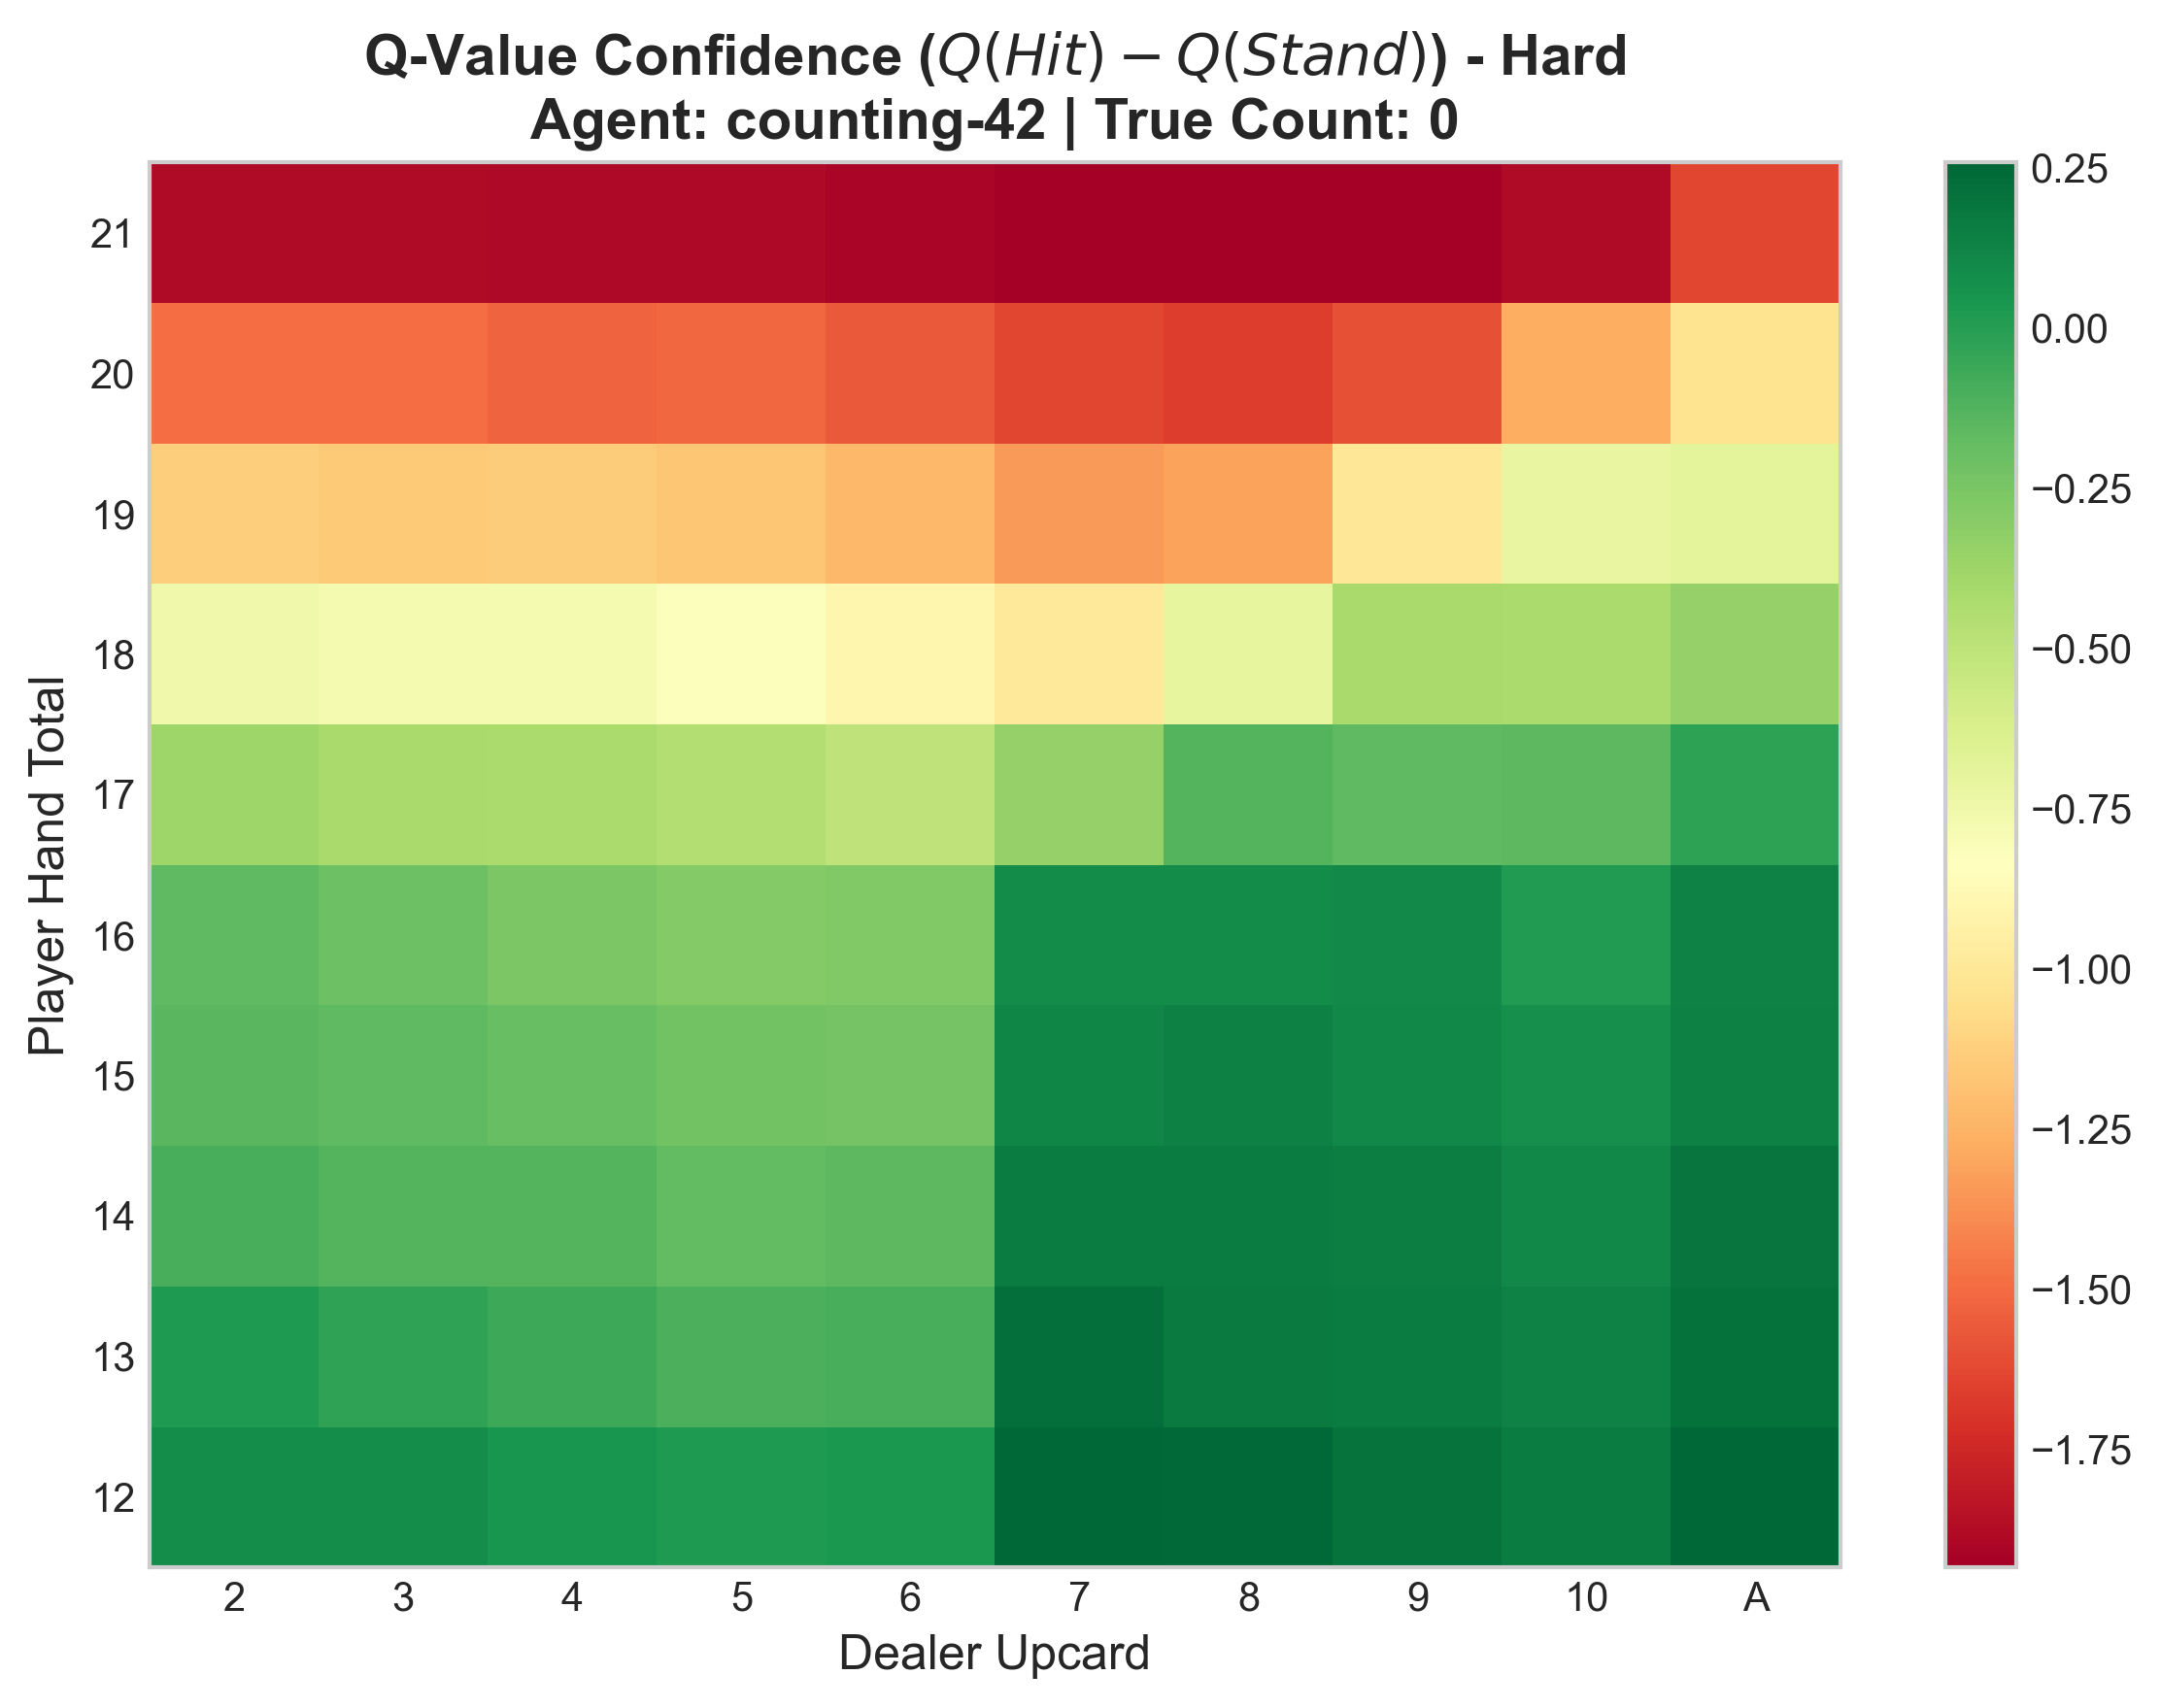

Policy-/Q-Value-Plots gespeichert: 24 Dateien


In [14]:
POLICY_REFERENCE_SEED = 42
POLICY_AGENT_NAMES = [
    f"baseline-{POLICY_REFERENCE_SEED}",
    f"counting-{POLICY_REFERENCE_SEED}",
]
POLICY_TRUE_COUNT_VALUES = (-3, 0, 3)

policy_agents = {}
for agent_name in POLICY_AGENT_NAMES:
    policy_agent, policy_source = selected_eval_agent(agent_name)
    policy_agents[agent_name] = policy_agent
    print(f"Policy-Modell für {agent_name}: {policy_source}")

policy_plot_paths = plot_all_agent_policy_and_q_values(
    agents=policy_agents,
    agent_names=POLICY_AGENT_NAMES,
    split_agent_name_func=split_agent_name,
    save_fig_func=save_fig,
    counting_true_counts=POLICY_TRUE_COUNT_VALUES,
)

policy_preview_paths = select_policy_preview_paths(
    policy_plot_paths,
    preferred_true_count=0,
)
display_saved_images(
    policy_preview_paths,
    title="Policy- und Q-Value-Analyse (Seed 42, kompakte Auswahl)",
)

policy_plot_count = sum(len(paths) for paths in policy_plot_paths.values())
print(f"Policy-/Q-Value-Plots gespeichert: {policy_plot_count} Dateien")


# 7. Ergebnisartefakte

- `images/training/`
- `images/evaluation/`
- `images/true_count/`
- `images/policy/`
- `models/evaluations/<RUN_ID>/`

Nicht mehr aktive oder ältere Varianten liegen unter `images/archive/`.
